# **Loading file**

In [467]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

In [468]:
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

print(Path.cwd())


/content


In [469]:
excel_files = list(Path.cwd().glob("*.xlsx"))
print(excel_files)

[PosixPath('/content/Wastewater_Effluent_and_Critical_Minerals_ML_Project.xlsx')]


In [470]:
import pandas as pd

data=pd.read_excel("Wastewater_Effluent_and_Critical_Minerals_ML_Project.xlsx", sheet_name="Shared Dataset")
print(data.shape)

(850, 36)


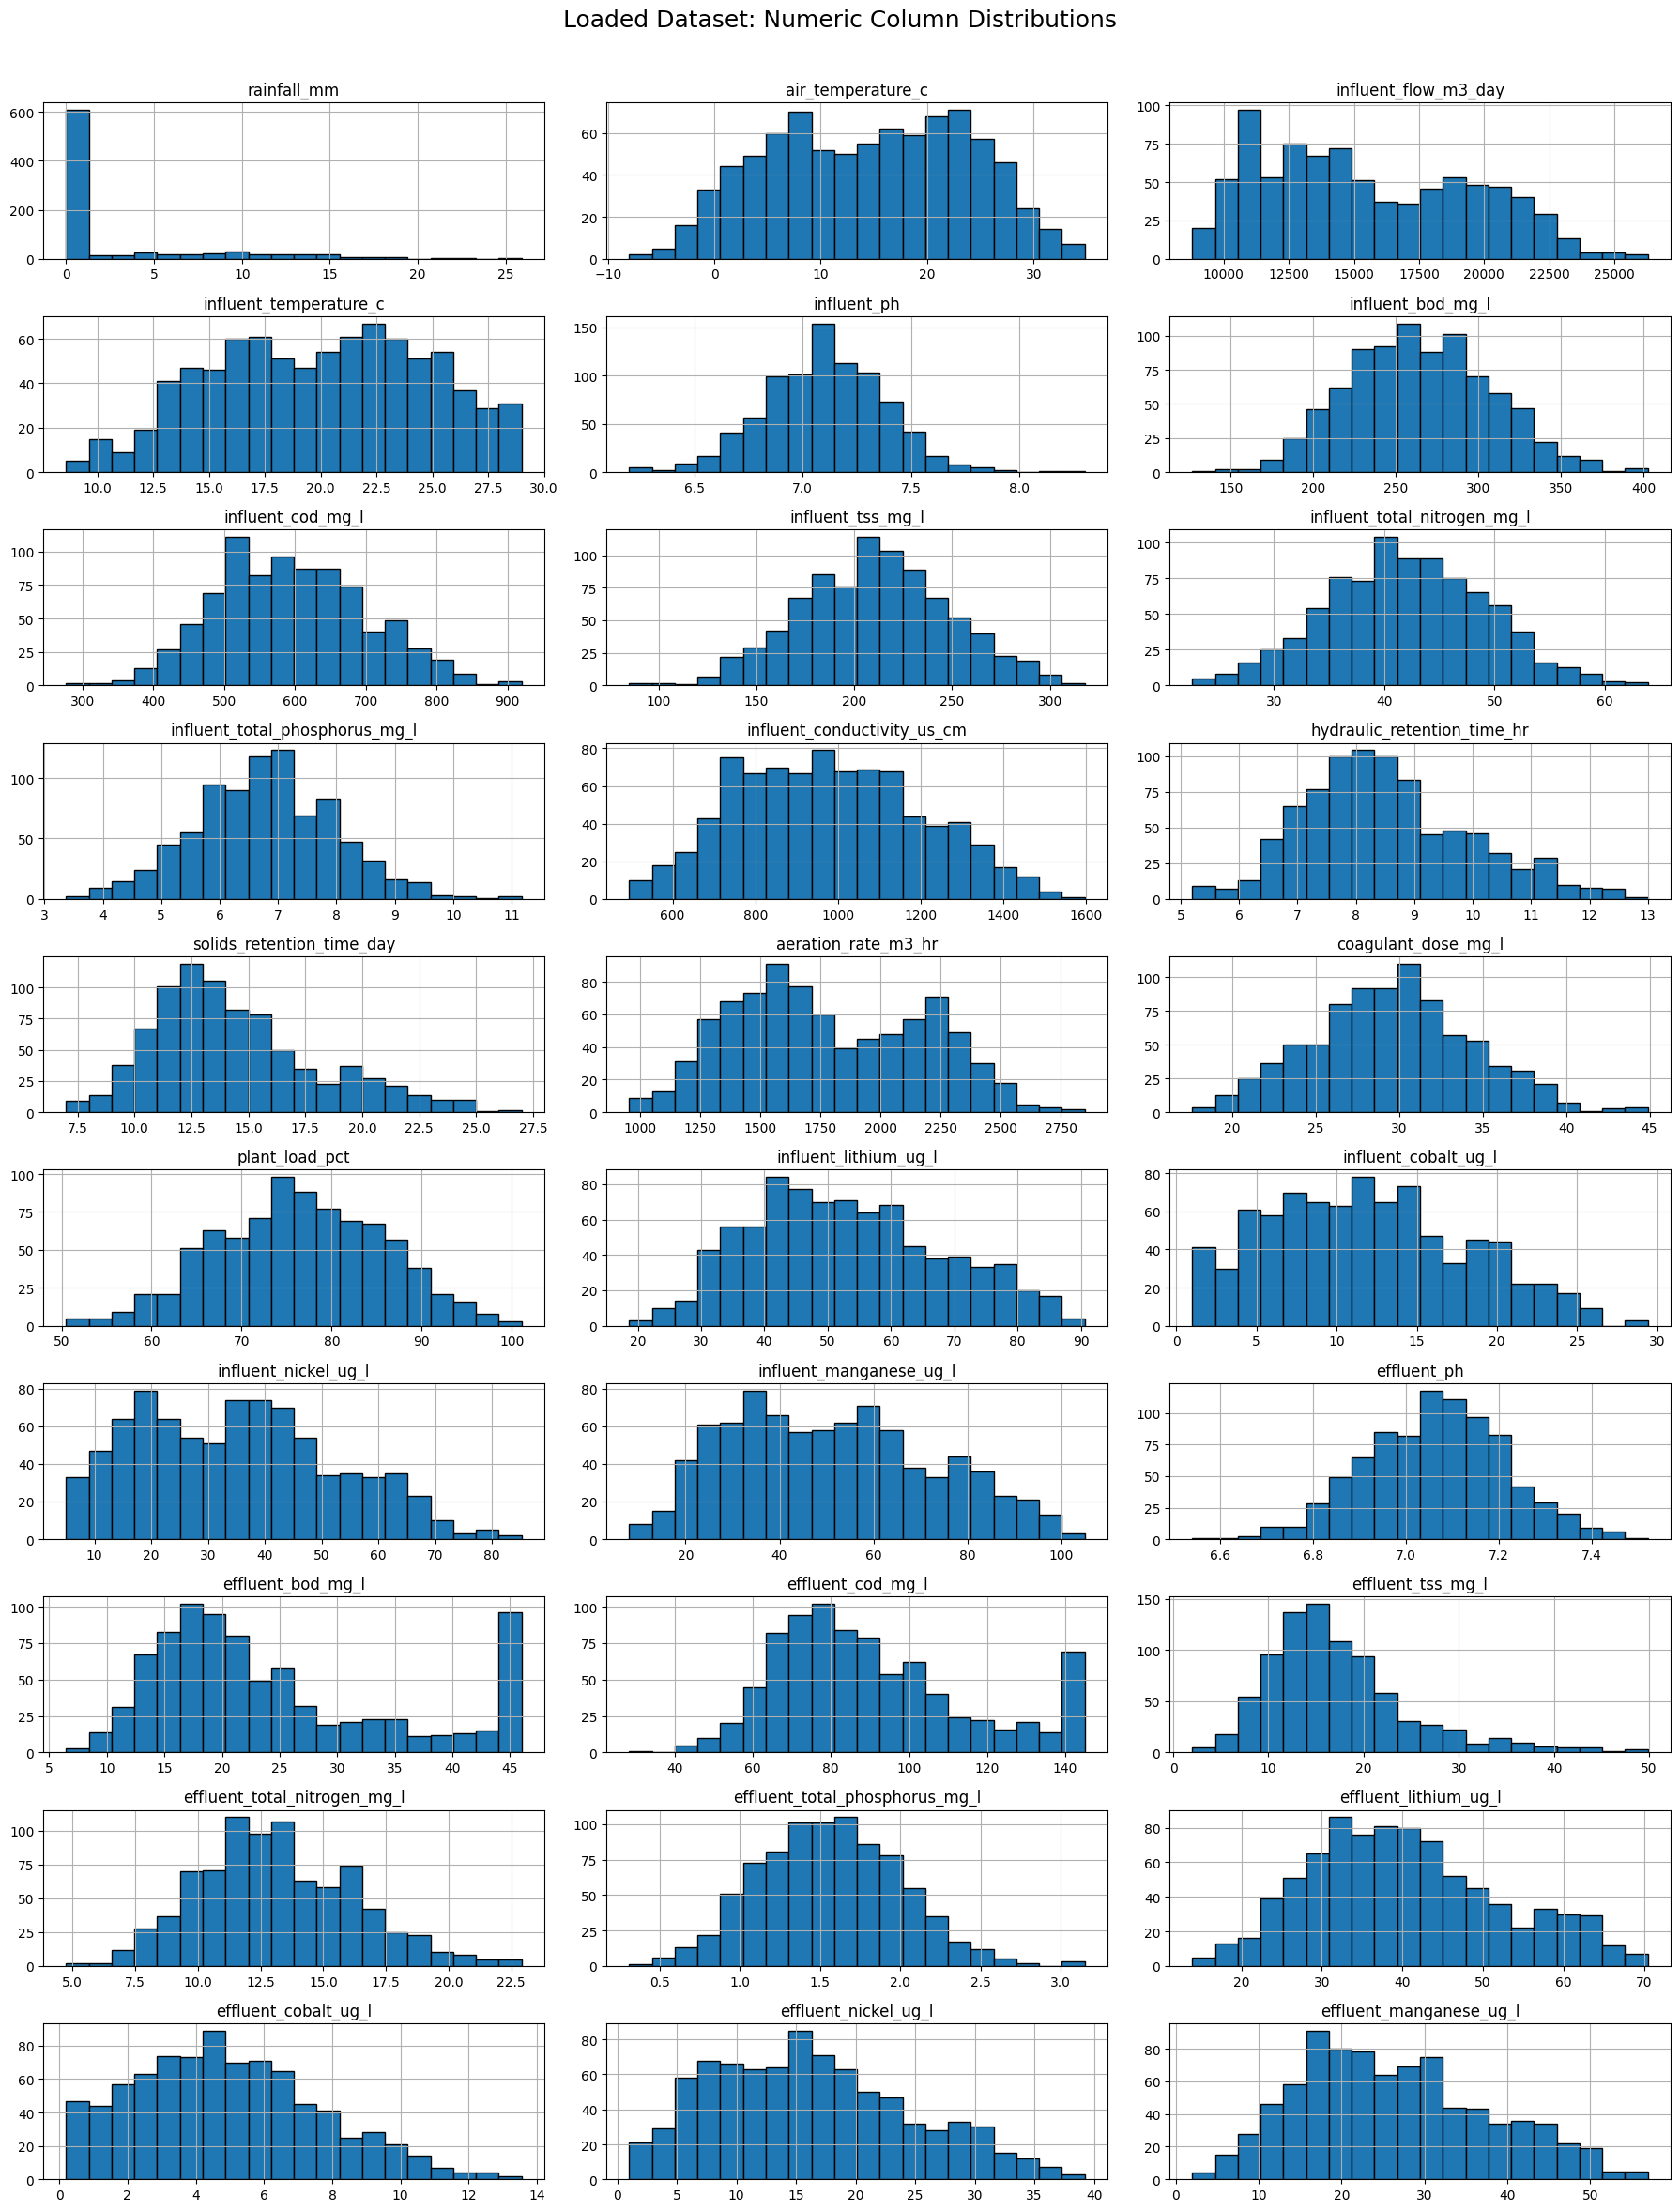

In [471]:
#plotting
# Loaded dataset: numeric distributions
numeric_data = data.select_dtypes(include="number")

numeric_data.hist(
    bins=20,
    figsize=(18, 24),
    layout=(10, 3),
    edgecolor="black"
)

plt.suptitle(
    "Loaded Dataset: Numeric Column Distributions",
    fontsize=18
)

plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


# **Data Inspection**

In [472]:
data.head()


,record_id,observation_date,plant_id,wastewater_source,treatment_process,season,rainfall_mm,air_temperature_c,influent_flow_m3_day,influent_temperature_c,...,effluent_ph,effluent_bod_mg_l,effluent_cod_mg_l,effluent_tss_mg_l,effluent_total_nitrogen_mg_l,effluent_total_phosphorus_mg_l,effluent_lithium_ug_l,effluent_cobalt_ug_l,effluent_nickel_ug_l,effluent_manganese_ug_l
0,WQ-0001,2024-01-01,WWTP-01,Municipal,Activated Sludge,Winter,0.0,1.0,14366.0,12.8,...,7.19,18.60,60.71,14.13,16.04,1.77,32.45,4.73,17.19,14.01
1,WQ-0002,2024-01-01,WWTP-02,Mixed Municipal-Industrial,Membrane Bioreactor,Winter,0.0,-1.4,19051.0,11.2,...,7.19,26.79,92.25,15.38,15.91,1.17,34.84,4.98,14.54,34.78
2,WQ-0003,2024-01-01,WWTP-03,Municipal,Trickling Filter,Winter,0.0,0.1,10440.0,10.6,...,7.34,21.22,64.43,14.33,10.96,1.26,28.57,2.64,6.27,10.21
3,WQ-0004,2024-01-01,WWTP-04,Industrial,Activated Sludge,Winter,0.0,-1.0,19115.0,11.9,...,7.07,46.00,145.00,29.55,17.94,2.79,45.46,9.08,29.38,36.47
4,WQ-0005,2024-01-01,WWTP-05,Mixed Municipal-Industrial,Sequencing Batch Reactor,Winter,0.0,6.2,12012.0,13.5,...,7.05,20.02,82.23,13.25,14.94,1.39,50.52,6.42,22.70,26.48


In [473]:
data.tail()

,record_id,observation_date,plant_id,wastewater_source,treatment_process,season,rainfall_mm,air_temperature_c,influent_flow_m3_day,influent_temperature_c,...,effluent_ph,effluent_bod_mg_l,effluent_cod_mg_l,effluent_tss_mg_l,effluent_total_nitrogen_mg_l,effluent_total_phosphorus_mg_l,effluent_lithium_ug_l,effluent_cobalt_ug_l,effluent_nickel_ug_l,effluent_manganese_ug_l
845,WQ-0846,2024-06-18,WWTP-01,Municipal,Activated Sludge,Summer,0.0,31.2,13290.0,29.0,...,7.05,17.13,74.85,12.52,12.15,1.39,38.78,5.71,7.76,19.63
846,WQ-0847,2024-06-18,WWTP-02,Mixed Municipal-Industrial,Membrane Bioreactor,Summer,0.0,30.9,19935.0,28.7,...,7.01,14.20,76.94,15.09,11.71,1.45,39.46,6.72,21.12,24.78
847,WQ-0848,2024-06-18,WWTP-03,Municipal,Trickling Filter,Summer,0.0,24.0,10823.0,25.6,...,7.16,20.30,64.74,9.09,12.78,1.26,35.01,4.92,10.47,10.96
848,WQ-0849,2024-06-18,WWTP-04,Industrial,Activated Sludge,Summer,12.3,18.6,19118.0,22.6,...,6.87,29.02,113.70,23.92,11.46,1.39,56.98,10.78,28.56,46.53
849,WQ-0850,2024-06-18,WWTP-05,Mixed Municipal-Industrial,Sequencing Batch Reactor,Summer,0.3,20.0,13530.0,22.5,...,7.35,15.40,66.63,10.79,17.05,1.46,32.53,4.80,17.02,33.10


In [474]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   record_id                       850 non-null    object        
 1   observation_date                850 non-null    datetime64[ns]
 2   plant_id                        850 non-null    object        
 3   wastewater_source               850 non-null    object        
 4   treatment_process               850 non-null    object        
 5   season                          850 non-null    object        
 6   rainfall_mm                     844 non-null    float64       
 7   air_temperature_c               844 non-null    float64       
 8   influent_flow_m3_day            847 non-null    float64       
 9   influent_temperature_c          845 non-null    float64       
 10  influent_ph                     849 non-null    float64       
 11  influe

In [475]:
data.columns

Index(['record_id', 'observation_date', 'plant_id', 'wastewater_source',
       'treatment_process', 'season', 'rainfall_mm', 'air_temperature_c',
       'influent_flow_m3_day', 'influent_temperature_c', 'influent_ph',
       'influent_bod_mg_l', 'influent_cod_mg_l', 'influent_tss_mg_l',
       'influent_total_nitrogen_mg_l', 'influent_total_phosphorus_mg_l',
       'influent_conductivity_us_cm', 'hydraulic_retention_time_hr',
       'solids_retention_time_day', 'aeration_rate_m3_hr',
       'coagulant_dose_mg_l', 'plant_load_pct', 'influent_lithium_ug_l',
       'influent_cobalt_ug_l', 'influent_nickel_ug_l',
       'influent_manganese_ug_l', 'effluent_ph', 'effluent_bod_mg_l',
       'effluent_cod_mg_l', 'effluent_tss_mg_l',
       'effluent_total_nitrogen_mg_l', 'effluent_total_phosphorus_mg_l',
       'effluent_lithium_ug_l', 'effluent_cobalt_ug_l', 'effluent_nickel_ug_l',
       'effluent_manganese_ug_l'],
      dtype='object')

In [476]:
data.dtypes

,0
record_id,object
observation_date,datetime64[ns]
plant_id,object
wastewater_source,object
treatment_process,object
season,object
rainfall_mm,float64
air_temperature_c,float64
influent_flow_m3_day,float64
influent_temperature_c,float64


In [477]:
data.describe()

,observation_date,rainfall_mm,air_temperature_c,influent_flow_m3_day,influent_temperature_c,influent_ph,influent_bod_mg_l,influent_cod_mg_l,influent_tss_mg_l,influent_total_nitrogen_mg_l,...,effluent_ph,effluent_bod_mg_l,effluent_cod_mg_l,effluent_tss_mg_l,effluent_total_nitrogen_mg_l,effluent_total_phosphorus_mg_l,effluent_lithium_ug_l,effluent_cobalt_ug_l,effluent_nickel_ug_l,effluent_manganese_ug_l
count,850,844.000000,844.000000,847.000000,845.000000,849.000000,849.000000,849.000000,850.000000,848.000000,...,849.000000,847.000000,844.000000,848.000000,850.000000,847.000000,850.000000,844.000000,845.000000,850.000000
mean,2024-03-25 12:00:00,2.728791,14.547749,15498.643447,19.975030,7.101355,264.619435,594.687515,210.586588,42.013915,...,7.062615,24.428760,90.741588,17.298514,13.145035,1.558442,40.369588,4.911919,16.300840,26.363729
min,2024-01-01 00:00:00,0.000000,-8.000000,8798.000000,8.600000,6.200000,126.700000,276.800000,85.000000,22.600000,...,6.540000,6.460000,28.340000,2.000000,4.740000,0.310000,13.910000,0.200000,1.000000,2.000000
25%,2024-02-12 00:00:00,0.000000,7.000000,12114.500000,16.300000,6.920000,234.800000,515.800000,184.125000,36.900000,...,6.960000,16.660000,72.705000,12.450000,11.005000,1.250000,31.567500,2.877500,9.610000,17.672500
50%,2024-03-25 12:00:00,0.000000,15.150000,14650.000000,20.200000,7.100000,262.500000,587.900000,210.000000,42.100000,...,7.060000,21.010000,85.295000,15.720000,12.825000,1.560000,39.135000,4.640000,15.530000,24.755000
75%,2024-05-07 00:00:00,3.725000,22.200000,18867.000000,23.700000,7.280000,294.400000,665.200000,235.175000,47.025000,...,7.160000,30.380000,103.600000,20.585000,15.242500,1.860000,47.972500,6.710000,21.620000,34.087500
max,2024-06-18 00:00:00,25.900000,34.800000,26281.000000,29.000000,8.300000,402.700000,920.000000,317.800000,63.900000,...,7.520000,46.000000,145.000000,49.860000,22.910000,3.150000,70.450000,13.550000,39.220000,56.940000
std,NaN,5.029317,9.242940,3993.474854,4.769463,0.278780,43.040568,105.732178,38.140161,7.244238,...,0.148963,10.660312,25.033639,7.574628,3.122442,0.441218,11.812453,2.706703,8.283441,11.322725


In [478]:
data.isna().sum().sum()

np.int64(95)

In [479]:
data.isna().any(axis=1).sum()

np.int64(88)

In [480]:
data["effluent_bod_mg_l"].isna().sum()


np.int64(3)

In [481]:
data["effluent_bod_mg_l"].notna().sum()

np.int64(847)

In [482]:
missing_counts=data.isna().sum()
missing_counts[missing_counts>0].index.tolist()

['rainfall_mm',
 'air_temperature_c',
 'influent_flow_m3_day',
 'influent_temperature_c',
 'influent_ph',
 'influent_bod_mg_l',
 'influent_cod_mg_l',
 'influent_total_nitrogen_mg_l',
 'influent_total_phosphorus_mg_l',
 'influent_conductivity_us_cm',
 'hydraulic_retention_time_hr',
 'solids_retention_time_day',
 'aeration_rate_m3_hr',
 'coagulant_dose_mg_l',
 'plant_load_pct',
 'influent_lithium_ug_l',
 'influent_cobalt_ug_l',
 'influent_nickel_ug_l',
 'effluent_ph',
 'effluent_bod_mg_l',
 'effluent_cod_mg_l',
 'effluent_tss_mg_l',
 'effluent_total_phosphorus_mg_l',
 'effluent_cobalt_ug_l',
 'effluent_nickel_ug_l']

In [483]:
missing_counts=data.isna().sum()
print("missing_counts:", missing_counts.sum(),missing_counts)


missing_counts: 95 record_id                         0
observation_date                  0
plant_id                          0
wastewater_source                 0
treatment_process                 0
season                            0
rainfall_mm                       6
air_temperature_c                 6
influent_flow_m3_day              3
influent_temperature_c            5
influent_ph                       1
influent_bod_mg_l                 1
influent_cod_mg_l                 1
influent_tss_mg_l                 0
influent_total_nitrogen_mg_l      2
influent_total_phosphorus_mg_l    5
influent_conductivity_us_cm       4
hydraulic_retention_time_hr       3
solids_retention_time_day         7
aeration_rate_m3_hr               4
coagulant_dose_mg_l               4
plant_load_pct                    4
influent_lithium_ug_l             3
influent_cobalt_ug_l              4
influent_nickel_ug_l              6
influent_manganese_ug_l           0
effluent_ph                       1
effluent_

In [484]:
print("Missing values column names(greater than zero) :")
missing_counts[missing_counts>0]

Missing values column names(greater than zero) :


,0
rainfall_mm,6
air_temperature_c,6
influent_flow_m3_day,3
influent_temperature_c,5
influent_ph,1
influent_bod_mg_l,1
influent_cod_mg_l,1
influent_total_nitrogen_mg_l,2
influent_total_phosphorus_mg_l,5
influent_conductivity_us_cm,4


In [485]:
missing_counts[missing_counts>0].sort_values(ascending=False)

,0
solids_retention_time_day,7
air_temperature_c,6
effluent_cod_mg_l,6
effluent_cobalt_ug_l,6
rainfall_mm,6
influent_nickel_ug_l,6
influent_temperature_c,5
influent_total_phosphorus_mg_l,5
effluent_nickel_ug_l,5
plant_load_pct,4


In [486]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
845,False
846,False
847,False
848,False


In [487]:
data.duplicated().sum()

np.int64(0)

In [488]:
data["record_id"].duplicated().sum()

np.int64(0)

In [489]:
#data.duplicated(subset=["plant_id","observation_date"])
data.duplicated(subset=["plant_id","observation_date"]).sum()

np.int64(0)

In [490]:
print("min:", data["observation_date"].min(),",", "max:", data["observation_date"].max())


min: 2024-01-01 00:00:00 , max: 2024-06-18 00:00:00


In [491]:
# 5 plants

data[["plant_id"]].value_counts()

,count
plant_id,
WWTP-01,170
WWTP-02,170
WWTP-03,170
WWTP-04,170
WWTP-05,170


In [492]:
display(data[["plant_id"]].head())

,plant_id
0,WWTP-01
1,WWTP-02
2,WWTP-03
3,WWTP-04
4,WWTP-05


**Unique** **values**

In [493]:
unique_counts = data.nunique(dropna=True);
print( unique_counts, unique_counts <= 1)

record_id                         850
observation_date                  170
plant_id                            5
wastewater_source                   3
treatment_process                   4
season                              3
rainfall_mm                       139
air_temperature_c                 324
influent_flow_m3_day              823
influent_temperature_c            188
influent_ph                       136
influent_bod_mg_l                 657
influent_cod_mg_l                 773
influent_tss_mg_l                 632
influent_total_nitrogen_mg_l      286
influent_total_phosphorus_mg_l    397
influent_conductivity_us_cm       537
hydraulic_retention_time_hr        74
solids_retention_time_day         155
aeration_rate_m3_hr               639
coagulant_dose_mg_l               207
plant_load_pct                    342
influent_lithium_ug_l             773
influent_cobalt_ug_l              702
influent_nickel_ug_l              781
influent_manganese_ug_l           794
effluent_ph 

In [494]:
data.loc[data["plant_load_pct"] > 100, ["record_id", "plant_id", "observation_date", "plant_load_pct"]]

,record_id,plant_id,observation_date,plant_load_pct
383,WQ-0384,WWTP-04,2024-03-17,101.1
596,WQ-0597,WWTP-02,2024-04-29,100.6


In [495]:
display(data.loc[data["effluent_bod_mg_l"].isna(),
                 ["record_id", "plant_id", "observation_date", "effluent_bod_mg_l"]])

,record_id,plant_id,observation_date,effluent_bod_mg_l
6,WQ-0007,WWTP-02,2024-01-02,NaN
51,WQ-0052,WWTP-02,2024-01-11,NaN
595,WQ-0596,WWTP-01,2024-04-29,NaN


In [496]:
data["effluent_bod_mg_l"].eq(46).sum()

np.int64(87)

In [497]:
display(data[[ "record_id", "plant_id", "observation_date", "plant_load_pct"]])

,record_id,plant_id,observation_date,plant_load_pct
0,WQ-0001,WWTP-01,2024-01-01,74.1
1,WQ-0002,WWTP-02,2024-01-01,82.9
2,WQ-0003,WWTP-03,2024-01-01,67.2
3,WQ-0004,WWTP-04,2024-01-01,89.7
4,WQ-0005,WWTP-05,2024-01-01,78.8
...,...,...,...,...
845,WQ-0846,WWTP-01,2024-06-18,66.5
846,WQ-0847,WWTP-02,2024-06-18,80.8
847,WQ-0848,WWTP-03,2024-06-18,71.3
848,WQ-0849,WWTP-04,2024-06-18,83.0


In [498]:
display(data[["rainfall_mm", "air_temperature_c","aeration_rate_m3_hr","coagulant_dose_mg_l","plant_load_pct"]].describe())

,rainfall_mm,air_temperature_c,aeration_rate_m3_hr,coagulant_dose_mg_l,plant_load_pct
count,844.000000,844.000000,846.000000,846.000000,846.000000
mean,2.728791,14.547749,1783.095745,29.605792,76.414657
std,5.029317,9.242940,392.900820,4.780164,9.332566
min,0.000000,-8.000000,955.000000,17.600000,50.500000
25%,0.000000,7.000000,1480.500000,26.400000,69.500000
50%,0.000000,15.150000,1718.000000,29.600000,76.200000
75%,3.725000,22.200000,2130.000000,32.600000,83.300000
max,25.900000,34.800000,2850.000000,44.900000,101.100000


In [499]:
data.filter(regex="^influent_").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
influent_flow_m3_day,847.0,15498.64,3993.47,8798.00,12114.50,14650.00,18867.00,26281.00
influent_temperature_c,845.0,19.98,4.77,8.60,16.30,20.20,23.70,29.00
influent_ph,849.0,7.10,0.28,6.20,6.92,7.10,7.28,8.30
influent_bod_mg_l,849.0,264.62,43.04,126.70,234.80,262.50,294.40,402.70
influent_cod_mg_l,849.0,594.69,105.73,276.80,515.80,587.90,665.20,920.00
influent_tss_mg_l,850.0,210.59,38.14,85.00,184.12,210.00,235.18,317.80
influent_total_nitrogen_mg_l,848.0,42.01,7.24,22.60,36.90,42.10,47.02,63.90
influent_total_phosphorus_mg_l,845.0,6.77,1.20,3.37,5.95,6.81,7.56,11.17
influent_conductivity_us_cm,846.0,979.49,221.90,495.00,806.00,968.00,1139.00,1597.00
influent_lithium_ug_l,847.0,52.97,15.08,18.64,41.70,51.56,63.08,90.60


In [500]:
data.filter(regex="^effluent_").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
effluent_ph,849.0,7.06,0.15,6.54,6.96,7.06,7.16,7.52
effluent_bod_mg_l,847.0,24.43,10.66,6.46,16.66,21.01,30.38,46.00
effluent_cod_mg_l,844.0,90.74,25.03,28.34,72.70,85.30,103.60,145.00
effluent_tss_mg_l,848.0,17.30,7.57,2.00,12.45,15.72,20.58,49.86
effluent_total_nitrogen_mg_l,850.0,13.15,3.12,4.74,11.00,12.82,15.24,22.91
effluent_total_phosphorus_mg_l,847.0,1.56,0.44,0.31,1.25,1.56,1.86,3.15
effluent_lithium_ug_l,850.0,40.37,11.81,13.91,31.57,39.14,47.97,70.45
effluent_cobalt_ug_l,844.0,4.91,2.71,0.20,2.88,4.64,6.71,13.55
effluent_nickel_ug_l,845.0,16.30,8.28,1.00,9.61,15.53,21.62,39.22
effluent_manganese_ug_l,850.0,26.36,11.32,2.00,17.67,24.76,34.09,56.94


In [501]:
season_counts = data["season"].value_counts()

season_table = season_counts.rename_axis("Season").reset_index(
    name="Observations"
)

display(season_table)

,Season,Observations
0,Spring,460
1,Winter,300
2,Summer,90


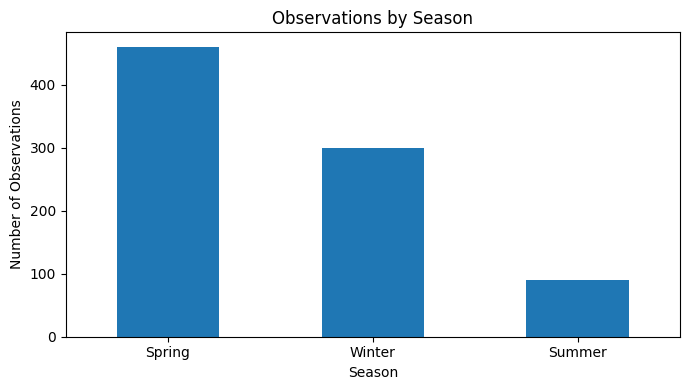

In [502]:
ax = season_table.plot.bar(
    x="Season",
    y="Observations",
    legend=False,
    rot=0,
    figsize=(7, 4)
)

ax.set_title("Observations by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

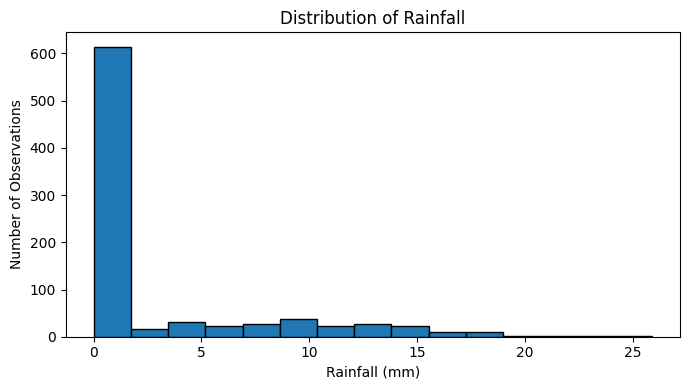

In [503]:
ax = data["rainfall_mm"].dropna().plot.hist(
    bins=15,
    edgecolor="black",
    figsize=(7, 4)
)

ax.set_title("Distribution of Rainfall")
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

In [504]:
data[["treatment_process"]].value_counts(dropna= False)

,count
treatment_process,
Activated Sludge,340
Membrane Bioreactor,170
Sequencing Batch Reactor,170
Trickling Filter,170


In [505]:
data[["wastewater_source"]].value_counts(dropna= False)

,count
wastewater_source,
Mixed Municipal-Industrial,340
Municipal,340
Industrial,170


In [506]:
data.loc[data["effluent_bod_mg_l"].isna(), ["record_id", "plant_id", "observation_date", "effluent_bod_mg_l"]]

,record_id,plant_id,observation_date,effluent_bod_mg_l
6,WQ-0007,WWTP-02,2024-01-02,NaN
51,WQ-0052,WWTP-02,2024-01-11,NaN
595,WQ-0596,WWTP-01,2024-04-29,NaN


In [507]:
missing_by_plant = data.isna().groupby(data["plant_id"]).sum()

display(missing_by_plant.loc[:, missing_counts > 0])

,rainfall_mm,air_temperature_c,influent_flow_m3_day,influent_temperature_c,influent_ph,influent_bod_mg_l,influent_cod_mg_l,influent_total_nitrogen_mg_l,influent_total_phosphorus_mg_l,influent_conductivity_us_cm,...,influent_lithium_ug_l,influent_cobalt_ug_l,influent_nickel_ug_l,effluent_ph,effluent_bod_mg_l,effluent_cod_mg_l,effluent_tss_mg_l,effluent_total_phosphorus_mg_l,effluent_cobalt_ug_l,effluent_nickel_ug_l
plant_id,,,,,,,,,,,,,,,,,,,,,
WWTP-01,2,0,0,0,0,0,0,1,2,2,...,1,2,1,0,1,1,2,0,2,1
WWTP-02,1,2,0,2,0,1,0,1,1,1,...,0,0,2,0,2,2,0,0,1,1
WWTP-03,1,1,1,1,0,0,0,0,0,1,...,0,0,1,0,0,1,0,1,0,1
WWTP-04,2,1,2,0,1,0,1,0,0,0,...,1,1,0,0,0,2,0,1,0,1
WWTP-05,0,2,0,2,0,0,0,0,2,0,...,1,1,2,1,0,0,0,1,3,1


In [508]:
minimum_temperature = data["air_temperature_c"].min()
print(minimum_temperature)

-8.0


In [509]:
display(
    data.loc[
        data["air_temperature_c"].eq(minimum_temperature),
        ["record_id", "plant_id", "observation_date", "air_temperature_c"]
    ]
)

,record_id,plant_id,observation_date,air_temperature_c
16,WQ-0017,WWTP-02,2024-01-04,-8.0


In [510]:
plant_profiles = data[
    ["plant_id", "wastewater_source", "treatment_process"]
].drop_duplicates()

display(plant_profiles)

,plant_id,wastewater_source,treatment_process
0,WWTP-01,Municipal,Activated Sludge
1,WWTP-02,Mixed Municipal-Industrial,Membrane Bioreactor
2,WWTP-03,Municipal,Trickling Filter
3,WWTP-04,Industrial,Activated Sludge
4,WWTP-05,Mixed Municipal-Industrial,Sequencing Batch Reactor


In [511]:
bod_at_46 = data.loc[
    data["effluent_bod_mg_l"].eq(46)
]

display(
    bod_at_46["plant_id"]
    .value_counts()
    .rename_axis("Plant")
    .reset_index(name="BOD equal to 46")
)

,Plant,BOD equal to 46
0,WWTP-04,78
1,WWTP-02,8
2,WWTP-05,1


In [512]:
target = "effluent_bod_mg_l"

In [513]:
effluent_columns = [
    column for column in data.columns
    if column.startswith("effluent_")
]

print(effluent_columns)

['effluent_ph', 'effluent_bod_mg_l', 'effluent_cod_mg_l', 'effluent_tss_mg_l', 'effluent_total_nitrogen_mg_l', 'effluent_total_phosphorus_mg_l', 'effluent_lithium_ug_l', 'effluent_cobalt_ug_l', 'effluent_nickel_ug_l', 'effluent_manganese_ug_l']


In [514]:
influent_columns=[
    column for column in data.columns
    if column.startswith("influent_")
]

print(influent_columns)

['influent_flow_m3_day', 'influent_temperature_c', 'influent_ph', 'influent_bod_mg_l', 'influent_cod_mg_l', 'influent_tss_mg_l', 'influent_total_nitrogen_mg_l', 'influent_total_phosphorus_mg_l', 'influent_conductivity_us_cm', 'influent_lithium_ug_l', 'influent_cobalt_ug_l', 'influent_nickel_ug_l', 'influent_manganese_ug_l']


In [515]:
excluded_columns = ["record_id"] + effluent_columns

print(excluded_columns)

['record_id', 'effluent_ph', 'effluent_bod_mg_l', 'effluent_cod_mg_l', 'effluent_tss_mg_l', 'effluent_total_nitrogen_mg_l', 'effluent_total_phosphorus_mg_l', 'effluent_lithium_ug_l', 'effluent_cobalt_ug_l', 'effluent_nickel_ug_l', 'effluent_manganese_ug_l']


In [516]:
categorical_candidates=["plant_id","wastewater_source","treatment_process","season"]

In [517]:
timing_review_features=["rainfall_mm","air_temperature_c","hydraulic_retention_time_hr",
                        "solids_retention_time_day","aeration_rate_m3_hr","coagulant_dose_mg_l","plant_load_pct"]

In [518]:
candidate_feature=influent_columns+ categorical_candidates
print(len(candidate_feature))

17


In [519]:
Candidates=data[candidate_feature].copy()
print(Candidates)

     influent_flow_m3_day  influent_temperature_c  influent_ph  \
0                 14366.0                    12.8         7.34   
1                 19051.0                    11.2         7.38   
2                 10440.0                    10.6         7.20   
3                 19115.0                    11.9         6.83   
4                 12012.0                    13.5         7.21   
..                    ...                     ...          ...   
845               13290.0                    29.0         7.05   
846               19935.0                    28.7         6.79   
847               10823.0                    25.6         7.07   
848               19118.0                    22.6         7.22   
849               13530.0                    22.5         7.37   

     influent_bod_mg_l  influent_cod_mg_l  influent_tss_mg_l  \
0                233.4              478.3              217.0   
1                296.5              703.5              222.1   
2              

In [520]:
Candidates.shape

(850, 17)

In [521]:
display(Candidates.head())

,influent_flow_m3_day,influent_temperature_c,influent_ph,influent_bod_mg_l,influent_cod_mg_l,influent_tss_mg_l,influent_total_nitrogen_mg_l,influent_total_phosphorus_mg_l,influent_conductivity_us_cm,influent_lithium_ug_l,influent_cobalt_ug_l,influent_nickel_ug_l,influent_manganese_ug_l,plant_id,wastewater_source,treatment_process,season
0,14366.0,12.8,7.34,233.4,478.3,217.0,47.3,7.26,722.0,39.77,10.56,29.57,29.87,WWTP-01,Municipal,Activated Sludge,Winter
1,19051.0,11.2,7.38,296.5,703.5,222.1,48.5,6.78,887.0,44.22,12.41,39.80,70.76,WWTP-02,Mixed Municipal-Industrial,Membrane Bioreactor,Winter
2,10440.0,10.6,7.20,197.2,477.2,183.1,34.3,4.91,731.0,37.83,3.91,18.04,28.24,WWTP-03,Municipal,Trickling Filter,Winter
3,19115.0,11.9,6.83,266.3,727.0,239.6,47.6,9.41,1179.0,65.47,22.03,60.73,77.66,WWTP-04,Industrial,Activated Sludge,Winter
4,12012.0,13.5,7.21,335.4,677.0,184.2,54.6,4.72,1080.0,67.75,14.16,49.40,49.62,WWTP-05,Mixed Municipal-Industrial,Sequencing Batch Reactor,Winter


In [522]:
valid_target_mask = data[target].notna()

In [523]:
#all 17 data(847 * 17)

X= Candidates.loc[valid_target_mask].copy()
print("All 17 Input table:\n",X)

All 17 Input table:
      influent_flow_m3_day  influent_temperature_c  influent_ph  \
0                 14366.0                    12.8         7.34   
1                 19051.0                    11.2         7.38   
2                 10440.0                    10.6         7.20   
3                 19115.0                    11.9         6.83   
4                 12012.0                    13.5         7.21   
..                    ...                     ...          ...   
845               13290.0                    29.0         7.05   
846               19935.0                    28.7         6.79   
847               10823.0                    25.6         7.07   
848               19118.0                    22.6         7.22   
849               13530.0                    22.5         7.37   

     influent_bod_mg_l  influent_cod_mg_l  influent_tss_mg_l  \
0                233.4              478.3              217.0   
1                296.5              703.5              222

In [524]:
y=data.loc[valid_target_mask,target].copy()
print(y)

0      18.60
1      26.79
2      21.22
3      46.00
4      20.02
       ...  
845    17.13
846    14.20
847    20.30
848    29.02
849    15.40
Name: effluent_bod_mg_l, Length: 847, dtype: float64


In [525]:
dates=data.loc[valid_target_mask,"observation_date"].copy()
print(dates)

0     2024-01-01
1     2024-01-01
2     2024-01-01
3     2024-01-01
4     2024-01-01
         ...    
845   2024-06-18
846   2024-06-18
847   2024-06-18
848   2024-06-18
849   2024-06-18
Name: observation_date, Length: 847, dtype: datetime64[ns]


In [526]:

print("Missing targets:", y.isna().sum())
print("Same row indices:", X.index.equals(y.index))

Missing targets: 0
Same row indices: True


# **Chronological train-validation-test Split**

In [527]:
unique_dates = dates.drop_duplicates().sort_values()
print(len(unique_dates))

170


In [528]:
train_end = int(len(unique_dates) * 0.60)
validation_end = int(len(unique_dates) * 0.80)
print("training data:",train_end,",", "validation data:", validation_end)

training data: 102 , validation data: 136


In [529]:
validation_start = unique_dates.iloc[train_end]
test_start = unique_dates.iloc[validation_end]
print(validation_start,",",test_start)

2024-04-12 00:00:00 , 2024-05-16 00:00:00


In [530]:
train_mask = dates < validation_start

validation_mask = (
    (dates >= validation_start) & (dates < test_start)
)

test_mask = dates >= test_start

In [531]:
print(test_mask)

0      False
1      False
2      False
3      False
4      False
       ...  
845     True
846     True
847     True
848     True
849     True
Name: observation_date, Length: 847, dtype: bool


# **Train Split**

In [532]:
X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
print(X_train, y_train)

     influent_flow_m3_day  influent_temperature_c  influent_ph  \
0                 14366.0                    12.8         7.34   
1                 19051.0                    11.2         7.38   
2                 10440.0                    10.6         7.20   
3                 19115.0                    11.9         6.83   
4                 12012.0                    13.5         7.21   
..                    ...                     ...          ...   
505               13660.0                    26.0         6.92   
506               20889.0                    23.4         7.05   
507                8822.0                    18.5         7.27   
508               17586.0                    19.8         7.00   
509               12506.0                    26.2         7.32   

     influent_bod_mg_l  influent_cod_mg_l  influent_tss_mg_l  \
0                233.4              478.3              217.0   
1                296.5              703.5              222.1   
2              

# **Validation Split**

In [533]:
X_validation= X.loc[validation_mask].copy()
y_validation=y.loc[validation_mask].copy()
print(X_validation,y_validation)

     influent_flow_m3_day  influent_temperature_c  influent_ph  \
510               16206.0                    14.9         6.86   
511               23071.0                    20.9         7.13   
512                9651.0                    21.1         7.20   
513               18943.0                    23.3         7.14   
514               11054.0                    23.3         7.20   
..                    ...                     ...          ...   
675               15443.0                    21.2         6.93   
676               21059.0                    23.5         7.40   
677                9645.0                    25.8         6.85   
678               18792.0                    20.0         6.89   
679               11642.0                    22.5         7.50   

     influent_bod_mg_l  influent_cod_mg_l  influent_tss_mg_l  \
510              169.8              359.9              238.0   
511              264.2              543.6              215.6   
512            

# **Test Split**

In [534]:
X_test =X.loc[test_mask].copy()
y_test=y.loc[test_mask].copy()
print("\n\ntest data(X):",X_test,",","\n\n\nTest_data(y):",y_test)



test data(X):      influent_flow_m3_day  influent_temperature_c  influent_ph  \
680               16113.0                    22.1         7.47   
681               20433.0                    25.3         7.38   
682               11862.0                     NaN         6.73   
683               12998.0                    27.0         6.89   
684               12029.0                    21.8         7.17   
..                    ...                     ...          ...   
845               13290.0                    29.0         7.05   
846               19935.0                    28.7         6.79   
847               10823.0                    25.6         7.07   
848               19118.0                    22.6         7.22   
849               13530.0                    22.5         7.37   

     influent_bod_mg_l  influent_cod_mg_l  influent_tss_mg_l  \
680              256.2              576.4              229.6   
681              265.1              609.8              224.9   

In [535]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

print(
    "All rows included:",
    len(X_train) + len(X_validation) + len(X_test) == len(X)
)

print(
    "Dates in correct order:",
    dates.loc[train_mask].max()
    < dates.loc[validation_mask].min()
    and dates.loc[validation_mask].max()
    < dates.loc[test_mask].min()
)

Train: (508, 17) (508,)
Validation: (169, 17) (169,)
Test: (170, 17) (170,)
All rows included: True
Dates in correct order: True


In [536]:
unique_dates = dates.drop_duplicates().sort_values()
train_end = int(len(unique_dates) * 0.60)
validation_end = int(len(unique_dates) * 0.80)
validation_start = unique_dates.iloc[train_end]
test_start = unique_dates.iloc[validation_end]
train_mask = dates < validation_start
validation_mask = (dates >= validation_start) & (dates < test_start)
test_mask = dates >= test_start
X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_validation, y_validation = X.loc[validation_mask].copy(), y.loc[validation_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()
assert len(X_train) + len(X_validation) + len(X_test) == len(X)
assert dates.loc[train_mask].max() < dates.loc[validation_mask].min()
assert dates.loc[validation_mask].max() < dates.loc[test_mask].min()
split_summary = pd.DataFrame([
    {"Split": name, "Rows": int(mask.sum()), "Start": dates.loc[mask].min(),
     "End": dates.loc[mask].max()}
    for name, mask in [("Train", train_mask), ("Validation", validation_mask), ("Test", test_mask)]
])
display(split_summary)

,Split,Rows,Start,End
0,Train,508,2024-01-01,2024-04-11
1,Validation,169,2024-04-12,2024-05-15
2,Test,170,2024-05-16,2024-06-18


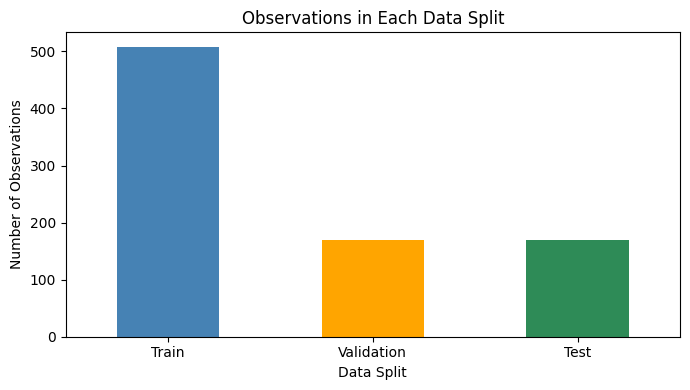

In [537]:
split_counts = pd.Series({
    "Train": len(X_train),
    "Validation": len(X_validation),
    "Test": len(X_test)
})

ax = split_counts.plot.bar(
    color=["steelblue", "orange", "seagreen"],
    rot=0,
    figsize=(7, 4)
)

ax.set_title("Observations in Each Data Split")
ax.set_xlabel("Data Split")
ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

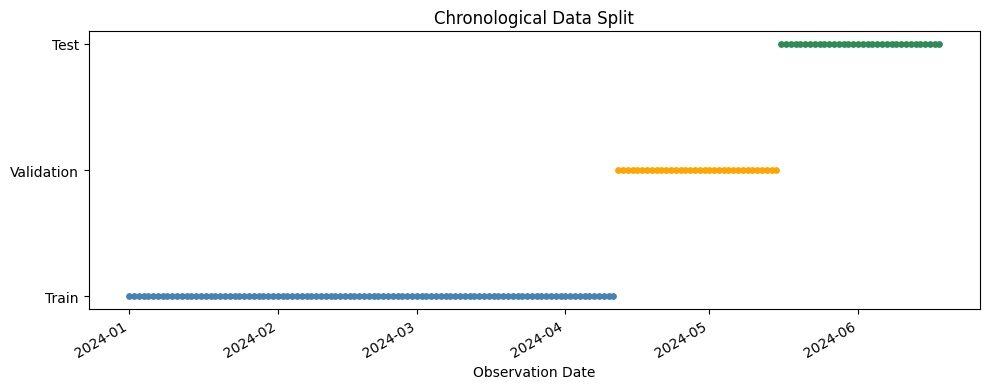

In [538]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, mask, level, color in [
    ("Train", train_mask, 0, "steelblue"),
    ("Validation", validation_mask, 1, "orange"),
    ("Test", test_mask, 2, "seagreen")
]:
    split_dates = dates.loc[mask].drop_duplicates()

    ax.scatter(
        split_dates,
        [level] * len(split_dates),
        label=label,
        color=color,
        s=15
    )

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Train", "Validation", "Test"])
ax.set_xlabel("Observation Date")
ax.set_title("Chronological Data Split")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# **Preprocessing**

In [539]:

# n separating the names of umerical, categorical columns

In [540]:
numeric_columns = X_train.select_dtypes(include="number").columns.tolist()

In [541]:
categorical_columns = X_train.select_dtypes(exclude="number").columns.tolist()

In [542]:
print("Numeric:", len(numeric_columns))
print("Categorical:", categorical_columns)

Numeric: 13
Categorical: ['plant_id', 'wastewater_source', 'treatment_process', 'season']


In [543]:
# counting missing values in Training data set
training_missing = X_train.isna().sum()

display(training_missing[training_missing > 0])

,0
influent_flow_m3_day,2
influent_temperature_c,2
influent_bod_mg_l,1
influent_cod_mg_l,1
influent_total_nitrogen_mg_l,2
influent_total_phosphorus_mg_l,2
influent_conductivity_us_cm,3
influent_cobalt_ug_l,3
influent_nickel_ug_l,4


In [544]:
numeric_pipeline = Pipeline( steps=[ ("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()) ])

categorical_pipeline = Pipeline( steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer( transformers=[("numeric", numeric_pipeline, numeric_columns),("categorical", categorical_pipeline, categorical_columns) ])

print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['influent_flow_m3_day',
                                  'influent_temperature_c', 'influent_ph',
                                  'influent_bod_mg_l', 'influent_cod_mg_l',
                                  'influent_tss_mg_l',
                                  'influent_total_nitrogen_mg_l',
                                  'influent_total_phosphorus_mg_l',
                                  'influent_conductivity_us_cm',
                                  'influent_lithium_ug_l',
                                  'influent_cobalt_ug_l',
                                  'influent_nickel_ug_l',
                                  'influent_manganese_ug_l']),
                            

In [545]:
models = {
    "Mean Baseline": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, solver="lsqr"),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
    "SVR": SVR(kernel="rbf", C=10.0, epsilon=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=10, weights="distance")
}

In [546]:
fitted_models = {}
predictions = {}
error_rows = []
for model_name, estimator in models.items():
    model = Pipeline([
        ("preprocessing", clone(preprocessor)),
        ("model", clone(estimator))
    ])
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    predictions[model_name] = {}
    for split_name, inputs, actual in [
        ("Train", X_train, y_train),
        ("Validation", X_validation, y_validation)
    ]:
        predicted = model.predict(inputs)
        predictions[model_name][split_name] = predicted
        mse = mean_squared_error(actual, predicted)
        error_rows.append({
            "Model": model_name, "Split": split_name,
            "MAE": mean_absolute_error(actual, predicted),
            "MSE": mse, "RMSE": np.sqrt(mse)
        })

In [547]:
error_table = pd.DataFrame(error_rows)
validation_order = (error_table.loc[error_table["Split"].eq("Validation")]
                    .sort_values("MAE")["Model"].tolist())

In [548]:

# Both tables share the validation-MAE ordering to make comparison easier.
def order_results(table):
    return (table.assign(
        _model_order=table["Model"].map({name: i for i, name in enumerate(validation_order)}),
        _split_order=table["Split"].map({"Train": 0, "Validation": 1})
    ).sort_values(["_model_order", "_split_order"])
      .drop(columns=["_model_order", "_split_order"]).reset_index(drop=True))
error_table = order_results(error_table)
display(error_table.round(3))

,Model,Split,MAE,MSE,RMSE
0,SVR,Train,3.714,39.288,6.268
1,SVR,Validation,6.015,76.000,8.718
2,Linear Regression,Train,5.185,47.654,6.903
3,Linear Regression,Validation,6.037,72.764,8.530
4,Ridge,Train,5.188,47.657,6.903
5,Ridge,Validation,6.046,72.826,8.534
6,Lasso,Train,5.270,48.203,6.943
7,Lasso,Validation,6.101,71.091,8.432
8,KNN,Train,0.000,0.000,0.000
9,KNN,Validation,6.140,71.556,8.459


In [549]:
relative_rows = []
for model_name, split_predictions in predictions.items():
    for split_name, actual in [("Train", y_train), ("Validation", y_validation)]:
        actual = np.asarray(actual, dtype=float)
        predicted = split_predictions[split_name]
        residuals = actual - predicted
        centered = actual - actual.mean()
        absolute_denominator = np.abs(centered).sum()
        squared_denominator = np.square(centered).sum()
        relative_rows.append({
            "Model": model_name, "Split": split_name,
            "R²": r2_score(actual, predicted) if squared_denominator > 0 else np.nan,
            "RAE": np.abs(residuals).sum() / absolute_denominator
                   if absolute_denominator > 0 else np.nan,
            "RRSE": np.sqrt(np.square(residuals).sum() / squared_denominator)
                    if squared_denominator > 0 else np.nan
        })
relative_table = order_results(pd.DataFrame(relative_rows))
display(relative_table.round(3))

,Model,Split,R²,RAE,RRSE
0,SVR,Train,0.650,0.433,0.592
1,SVR,Validation,0.408,0.636,0.769
2,Linear Regression,Train,0.576,0.605,0.651
3,Linear Regression,Validation,0.433,0.639,0.753
4,Ridge,Train,0.576,0.605,0.652
5,Ridge,Validation,0.433,0.640,0.753
6,Lasso,Train,0.571,0.615,0.655
7,Lasso,Validation,0.446,0.646,0.744
8,KNN,Train,1.000,0.000,0.000
9,KNN,Validation,0.443,0.650,0.747


In [550]:
import matplotlib.pyplot as plt

# Same model order in every plot: lowest validation MAE first
model_order = (
    error_table[error_table["Split"] == "Validation"]
    .sort_values("MAE")["Model"]
    .tolist()
)

plot_settings = [
    (error_table, "MAE", "MAE (mg/L)", "Lower is better"),
    (error_table, "MSE", "MSE ((mg/L)²)", "Lower is better"),
    (error_table, "RMSE", "RMSE (mg/L)", "Lower is better"),
    (relative_table, "R²", "R² score", "Higher is better"),
    (relative_table, "RAE", "RAE ratio", "Lower is better"),
    (relative_table, "RRSE", "RRSE ratio", "Lower is better")
]



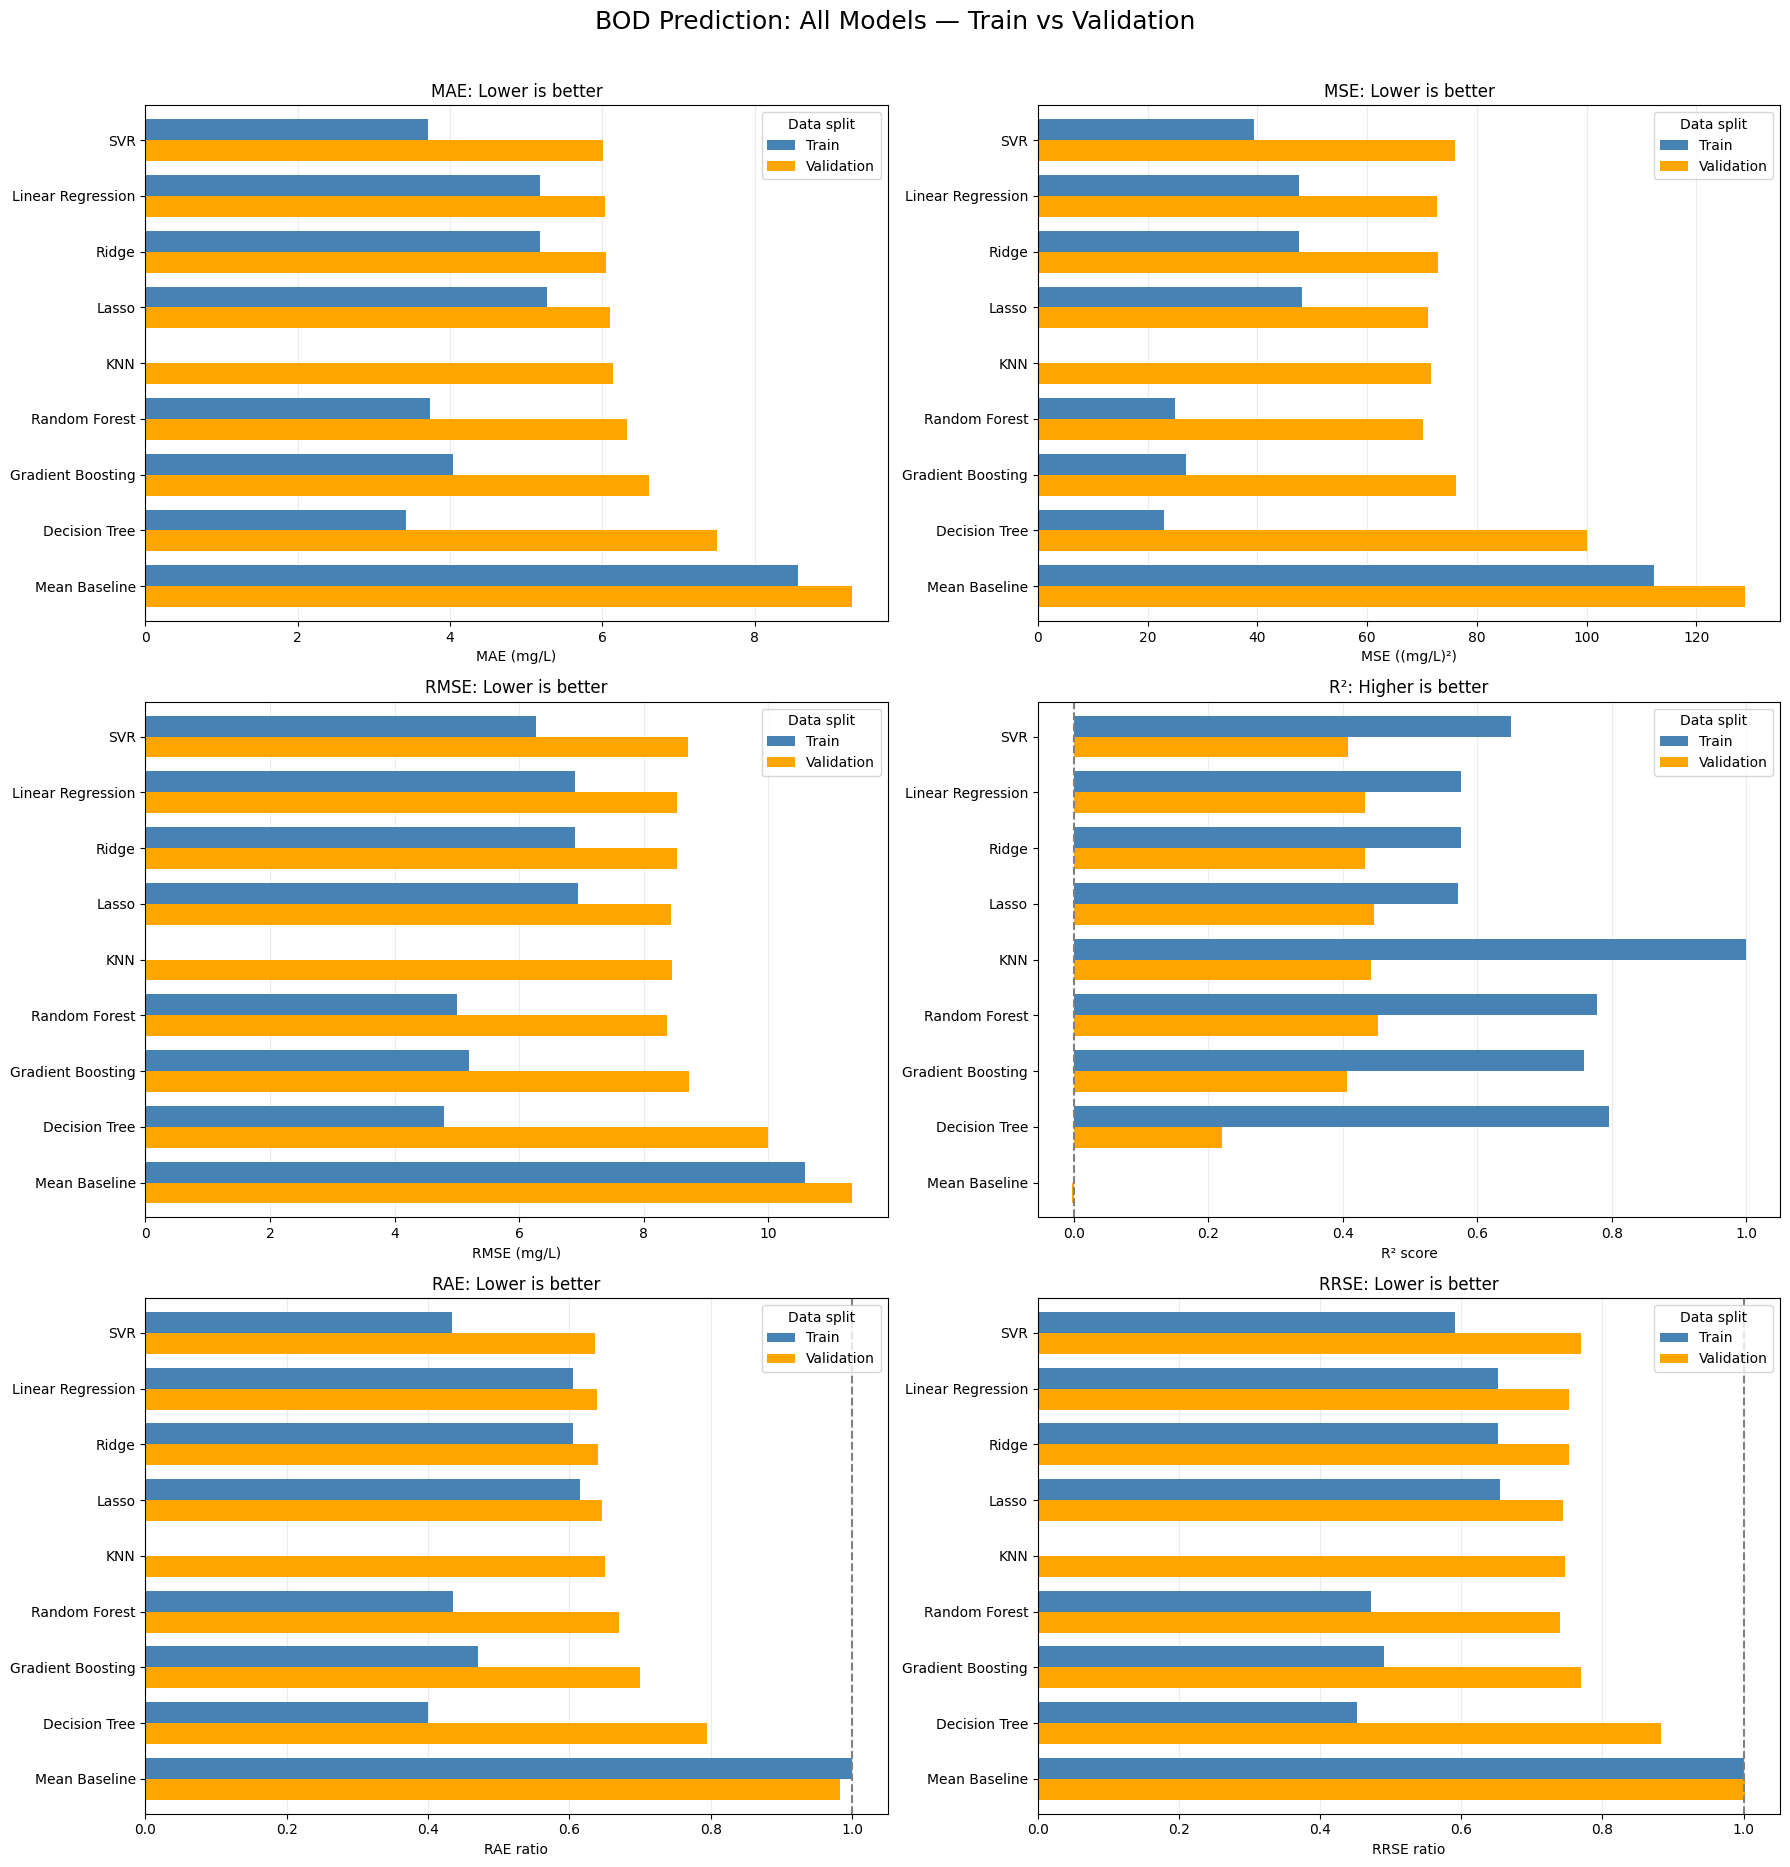

In [551]:
fig, axes = plt.subplots(3, 2, figsize=(18, 19))

for ax, (table, metric, label, direction) in zip(
    axes.flat, plot_settings
):
    plot_data = (
        table.pivot(
            index="Model",
            columns="Split",
            values=metric
        )
        .reindex(model_order)[["Train", "Validation"]]
    )

    plot_data.plot.barh(
        ax=ax,
        color=["steelblue", "orange"],
        width=0.75
    )

    ax.invert_yaxis()
    ax.set_title(f"{metric}: {direction}")
    ax.set_xlabel(label)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(title="Data split")

    if metric == "R²":
        ax.axvline(0, color="gray", linestyle="--")
    elif metric in ["RAE", "RRSE"]:
        ax.axvline(
            1,
            color="gray",
            linestyle="--"
        )

fig.suptitle(
    "BOD Prediction: All Models — Train vs Validation",
    fontsize=18
)

plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

only to see validation results (to analyze the model performance)

In [552]:
validation_summary = (
    error_table[error_table["Split"] == "Validation"]
    .merge(
        relative_table[relative_table["Split"] == "Validation"],
        on=["Model", "Split"],
        validate="one_to_one"
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(validation_summary.round(3))

,Model,Split,MAE,MSE,RMSE,R²,RAE,RRSE
0,SVR,Validation,6.015,76.000,8.718,0.408,0.636,0.769
1,Linear Regression,Validation,6.037,72.764,8.530,0.433,0.639,0.753
2,Ridge,Validation,6.046,72.826,8.534,0.433,0.640,0.753
3,Lasso,Validation,6.101,71.091,8.432,0.446,0.646,0.744
4,KNN,Validation,6.140,71.556,8.459,0.443,0.650,0.747
5,Random Forest,Validation,6.326,70.241,8.381,0.453,0.669,0.740
6,Gradient Boosting,Validation,6.609,76.157,8.727,0.407,0.699,0.770
7,Decision Tree,Validation,7.507,100.025,10.001,0.221,0.794,0.883
8,Mean Baseline,Validation,9.282,128.787,11.348,-0.003,0.982,1.002


In [553]:
gap_table = error_table.pivot(
    index="Model",
    columns="Split",
    values="MAE"
)

gap_table["MAE_Gap"] = (
    gap_table["Validation"] - gap_table["Train"]
)

display(
    gap_table.sort_values("Validation").round(3)
)

Split,Train,Validation,MAE_Gap
Model,,,
SVR,3.714,6.015,2.301
Linear Regression,5.185,6.037,0.852
Ridge,5.188,6.046,0.858
Lasso,5.270,6.101,0.831
KNN,0.000,6.140,6.140
Random Forest,3.733,6.326,2.593
Gradient Boosting,4.038,6.609,2.571
Decision Tree,3.424,7.507,4.083
Mean Baseline,8.570,9.282,0.712


In [554]:
best_model_name = validation_summary.iloc[0]["Model"]

best_model = fitted_models[best_model_name]

best_validation_predictions = (
    predictions[best_model_name]["Validation"]
)

print("Selected candidate:", best_model_name)

display(validation_summary.head(1).round(3))

Selected candidate: SVR


,Model,Split,MAE,MSE,RMSE,R²,RAE,RRSE
0,SVR,Validation,6.015,76.0,8.718,0.408,0.636,0.769


***SVR performed best based on validation MAE***


We chose MAE as our primary metric because it directly measures the average absolute prediction error in mg/L. SVR had the lowest validation MAE among the eight tested models.
However, SVR’s advantage over Linear Regression is only 0.022 mg/L. That small difference does not establish a clear, reliable advantage. Your plant analysis also shows uneven performance: MAE is 9.815 at WWTP-02, compared with 3.529 at WWTP-03.

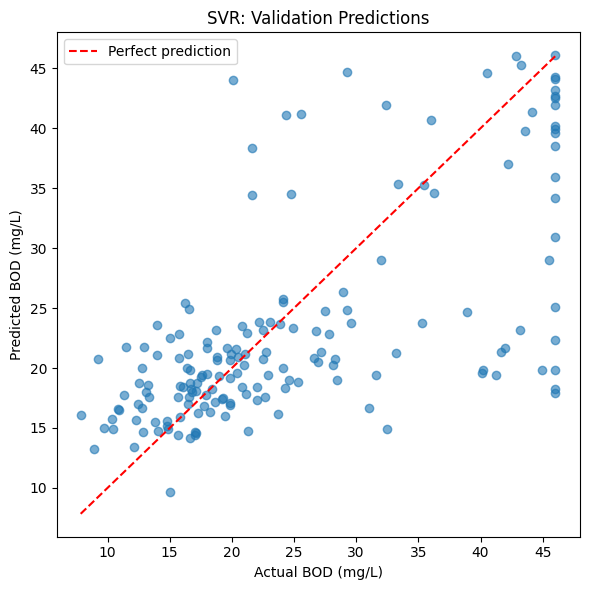

In [555]:
actual = y_validation.to_numpy()
predicted = best_validation_predictions

lower = min(actual.min(), predicted.min())
upper = max(actual.max(), predicted.max())

plt.figure(figsize=(6, 6))

plt.scatter(
    actual,
    predicted,
    alpha=0.6
)

plt.plot(
    [lower, upper],
    [lower, upper],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual BOD (mg/L)")
plt.ylabel("Predicted BOD (mg/L)")
plt.title(f"{best_model_name}: Validation Predictions")
plt.legend()
plt.tight_layout()
plt.show()

In [556]:
validation_errors = pd.DataFrame({
    "Plant": X_validation["plant_id"].to_numpy(),
    "Actual": actual,
    "Predicted": predicted
})

validation_errors["Residual"] = (
    validation_errors["Actual"]
    - validation_errors["Predicted"]
)

validation_errors["Absolute_Error"] = (
    validation_errors["Residual"].abs()
)

plant_error_table = (
    validation_errors.groupby("Plant")
    .agg(
        Observations=("Absolute_Error", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(plant_error_table.round(3))

,Observations,MAE,Mean_Residual
Plant,,,
WWTP-02,34,9.815,3.431
WWTP-04,34,7.333,-0.693
WWTP-05,34,5.692,3.268
WWTP-01,33,3.634,0.915
WWTP-03,34,3.529,0.731


# **BOD test evaluation**

In [557]:
#Fix the selected model


from sklearn.base import clone
from sklearn.dummy import DummyRegressor

selected_model_name = best_model_name

final_model = clone(fitted_models[selected_model_name])

print("Selected model:", selected_model_name)
print("Settings:", final_model.named_steps["model"])

Selected model: SVR
Settings: SVR(C=10.0)


In [558]:
#Combine training and validation data

X_development = pd.concat(
    [X_train, X_validation]
)

y_development = pd.concat(
    [y_train, y_validation]
)

assert X_development.index.equals(y_development.index)
assert X_development.index.intersection(X_test.index).empty

print("Final fitting rows:", len(X_development))
print("Test rows:", len(X_test))

Final fitting rows: 677
Test rows: 170


In [559]:
#Fit the final model and baseline


final_model.fit(X_development, y_development)

test_predictions = final_model.predict(X_test)

final_baseline = DummyRegressor(strategy="mean")

final_baseline.fit(X_development, y_development)

baseline_test_predictions = final_baseline.predict(X_test)

In [560]:
#Calculate the final test metrics


test_actual = y_test.to_numpy(dtype=float)

centered = test_actual - test_actual.mean()

absolute_denominator = np.abs(centered).sum()
squared_denominator = np.square(centered).sum()

test_rows = []

for name, predicted_values in [
    (selected_model_name, test_predictions),
    ("Mean Baseline", baseline_test_predictions)
]:
    residuals = test_actual - predicted_values

    mse = mean_squared_error(
        test_actual, predicted_values
    )

    test_rows.append({
        "Model": name,
        "Split": "Test",
        "MAE": mean_absolute_error(
            test_actual, predicted_values
        ),
        "RMSE": np.sqrt(mse),
        "R²": (
            r2_score(test_actual, predicted_values)
            if squared_denominator > 0 else np.nan
        ),
        "RAE": (
            np.abs(residuals).sum() / absolute_denominator
            if absolute_denominator > 0 else np.nan
        ),
        "RRSE": (
            np.sqrt(
                np.square(residuals).sum()
                / squared_denominator
            )
            if squared_denominator > 0 else np.nan
        )
    })

test_results = pd.DataFrame(test_rows)

display(test_results.round(3))

,Model,Split,MAE,RMSE,R²,RAE,RRSE
0,SVR,Test,5.667,7.861,0.395,0.689,0.778
1,Mean Baseline,Test,8.226,10.105,-0.000,1.000,1.000


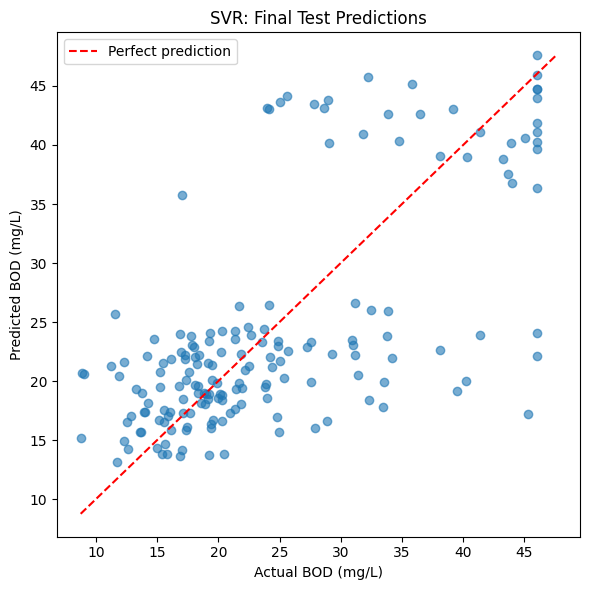

In [561]:
#Plot final test predictions

lower = min(
    test_actual.min(), test_predictions.min()
)

upper = max(
    test_actual.max(), test_predictions.max()
)

plt.figure(figsize=(6, 6))

plt.scatter(
    test_actual,
    test_predictions,
    alpha=0.6
)

plt.plot(
    [lower, upper],
    [lower, upper],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual BOD (mg/L)")
plt.ylabel("Predicted BOD (mg/L)")
plt.title(f"{selected_model_name}: Final Test Predictions")
plt.legend()
plt.tight_layout()
plt.show()

SVR reduced MAE by approximately 31.1% compared with the baseline. R² = 0.395 does not mean 39.5% accuracy. The scatter plot still shows some large prediction errors.
Next, add these 5 cells to document and save this BOD result. No retraining is needed.

In [562]:
#Calculate improvement over baseline

model_mae = test_results.loc[
    test_results["Model"] == selected_model_name, "MAE"
].iloc[0]

baseline_mae = test_results.loc[
    test_results["Model"] == "Mean Baseline", "MAE"
].iloc[0]

improvement_pct = (
    (baseline_mae - model_mae) / baseline_mae
) * 100

print(f"Test MAE: {model_mae:.3f} mg/L")
print(f"MAE reduction versus baseline: {improvement_pct:.2f}%")

Test MAE: 5.667 mg/L
MAE reduction versus baseline: 31.10%


In [563]:
#Create a table of individual test predictions

test_prediction_table = data.loc[
    X_test.index,
    ["record_id", "plant_id", "observation_date"]
].copy()

test_prediction_table["Actual_BOD"] = test_actual
test_prediction_table["Predicted_BOD"] = test_predictions

test_prediction_table["Residual"] = (
    test_prediction_table["Actual_BOD"]
    - test_prediction_table["Predicted_BOD"]
)

test_prediction_table["Absolute_Error"] = (
    test_prediction_table["Residual"].abs()
)

display(test_prediction_table.head(10).round(3))

,record_id,plant_id,observation_date,Actual_BOD,Predicted_BOD,Residual,Absolute_Error
680,WQ-0681,WWTP-01,2024-05-16,30.94,23.439,7.501,7.501
681,WQ-0682,WWTP-02,2024-05-16,21.42,19.302,2.118,2.118
682,WQ-0683,WWTP-03,2024-05-16,15.47,21.530,-6.060,6.060
683,WQ-0684,WWTP-04,2024-05-16,46.00,44.760,1.240,1.240
684,WQ-0685,WWTP-05,2024-05-16,18.11,19.705,-1.595,1.595
685,WQ-0686,WWTP-01,2024-05-17,21.68,19.817,1.863,1.863
686,WQ-0687,WWTP-02,2024-05-17,31.00,23.076,7.924,7.924
687,WQ-0688,WWTP-03,2024-05-17,19.46,21.405,-1.945,1.945
688,WQ-0689,WWTP-04,2024-05-17,46.00,39.635,6.365,6.365
689,WQ-0690,WWTP-05,2024-05-17,16.12,21.903,-5.783,5.783


In [564]:
#Check test performance by plant


test_plant_results = (
    test_prediction_table.groupby("plant_id")
    .agg(
        Observations=("Absolute_Error", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(test_plant_results.round(3))

,Observations,MAE,Mean_Residual
plant_id,,,
WWTP-02,34,9.380,2.987
WWTP-04,34,8.003,-4.297
WWTP-05,34,4.147,0.781
WWTP-01,34,3.858,1.252
WWTP-03,34,2.948,0.203


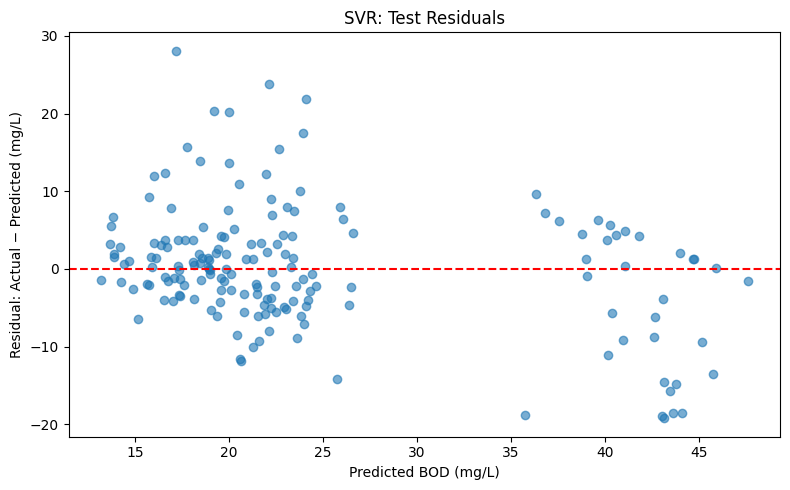

In [565]:
#Plot test residuals


plt.figure(figsize=(8, 5))

plt.scatter(
    test_prediction_table["Predicted_BOD"],
    test_prediction_table["Residual"],
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted BOD (mg/L)")
plt.ylabel("Residual: Actual − Predicted (mg/L)")
plt.title("SVR: Test Residuals")
plt.tight_layout()
plt.show()

In [566]:
#Save the pipeline and results

from pathlib import Path
import joblib

output_dir = Path("bod_results")
output_dir.mkdir(exist_ok=True)

joblib.dump(
    {
        "pipeline": final_model,
        "target": target,
        "feature_columns": X_development.columns.tolist(),
        "selection_metric": "Validation MAE",
        "model_name": selected_model_name
    },
    output_dir / "bod_svr_pipeline.joblib"
)

test_results.to_csv(
    output_dir / "test_metrics.csv",
    index=False
)

test_prediction_table.to_csv(
    output_dir / "test_predictions.csv",
    index=False
)

test_plant_results.to_csv(
    output_dir / "test_metrics_by_plant.csv"
)

print("Saved files:")
for path in sorted(output_dir.iterdir()):
    print(path)

Saved files:
bod_results/bod_svr_pipeline.joblib
bod_results/test_metrics.csv
bod_results/test_metrics_by_plant.csv
bod_results/test_predictions.csv


# **COD test evaluation and model comparison**





In [567]:
#Prepare COD inputs and target

cod_target = "effluent_cod_mg_l"

cod_valid_mask = data[cod_target].notna()

cod_X = data.loc[
    cod_valid_mask, candidate_feature
].copy()

cod_y = data.loc[
    cod_valid_mask, cod_target
].copy()

cod_dates = data.loc[
    cod_valid_mask, "observation_date"
].copy()

assert cod_X.index.equals(cod_y.index)

print("Target:", cod_target)
print("Input shape:", cod_X.shape)
print("Missing COD targets excluded:", (~cod_valid_mask).sum())

Target: effluent_cod_mg_l
Input shape: (844, 17)
Missing COD targets excluded: 6


In [568]:
#Apply the same date boundaries

cod_train_mask = cod_dates < validation_start

cod_validation_mask = (
    (cod_dates >= validation_start)
    & (cod_dates < test_start)
)

cod_test_mask = cod_dates >= test_start

cod_X_train = cod_X.loc[cod_train_mask].copy()
cod_y_train = cod_y.loc[cod_train_mask].copy()

cod_X_validation = cod_X.loc[cod_validation_mask].copy()
cod_y_validation = cod_y.loc[cod_validation_mask].copy()

cod_X_test = cod_X.loc[cod_test_mask].copy()
cod_y_test = cod_y.loc[cod_test_mask].copy()

assert (
    len(cod_X_train)
    + len(cod_X_validation)
    + len(cod_X_test)
    == len(cod_X)
)

print("Train:", cod_X_train.shape)
print("Validation:", cod_X_validation.shape)
print("Test:", cod_X_test.shape)

Train: (505, 17)
Validation: (170, 17)
Test: (169, 17)


In [569]:
#Train all models once and calculate metrics

cod_fitted_models = {}
cod_predictions = {}
cod_metric_rows = []

for name, estimator in models.items():

    model = Pipeline([
        ("preprocessing", clone(preprocessor)),
        ("model", clone(estimator))
    ])

    model.fit(cod_X_train, cod_y_train)

    cod_fitted_models[name] = model
    cod_predictions[name] = {}

    for split, inputs, actual_values in [
        ("Train", cod_X_train, cod_y_train),
        ("Validation", cod_X_validation, cod_y_validation)
    ]:
        actual_values = actual_values.to_numpy(dtype=float)
        predicted_values = model.predict(inputs)

        cod_predictions[name][split] = predicted_values

        residuals = actual_values - predicted_values
        centered = actual_values - actual_values.mean()

        absolute_denominator = np.abs(centered).sum()
        squared_denominator = np.square(centered).sum()

        mse = mean_squared_error(
            actual_values, predicted_values
        )

        cod_metric_rows.append({
            "Model": name,
            "Split": split,
            "MAE": mean_absolute_error(
                actual_values, predicted_values
            ),
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": (
                r2_score(actual_values, predicted_values)
                if squared_denominator > 0 else np.nan
            ),
            "RAE": (
                np.abs(residuals).sum()
                / absolute_denominator
                if absolute_denominator > 0 else np.nan
            ),
            "RRSE": (
                np.sqrt(
                    np.square(residuals).sum()
                    / squared_denominator
                )
                if squared_denominator > 0 else np.nan
            )
        })

cod_metrics = pd.DataFrame(cod_metric_rows)

print("COD models trained:", len(cod_fitted_models))

COD models trained: 9


In [570]:
#Display the two comparison tables


cod_validation_ranking = (
    cod_metrics[cod_metrics["Split"] == "Validation"]
    .sort_values("MAE")
    .reset_index(drop=True)
)

cod_model_order = cod_validation_ranking["Model"].tolist()

cod_ordered_metrics = (
    cod_metrics.assign(
        Model_Order=cod_metrics["Model"].map({
            name: i
            for i, name in enumerate(cod_model_order)
        }),
        Split_Order=cod_metrics["Split"].map({
            "Train": 0,
            "Validation": 1
        })
    )
    .sort_values(["Model_Order", "Split_Order"])
    .drop(columns=["Model_Order", "Split_Order"])
    .reset_index(drop=True)
)

cod_error_table = cod_ordered_metrics[
    ["Model", "Split", "MAE", "MSE", "RMSE"]
].copy()

cod_relative_table = cod_ordered_metrics[
    ["Model", "Split", "R²", "RAE", "RRSE"]
].copy()

print("Table 1: COD error metrics", "Table 2: COD relative metrics")
display(cod_error_table.round(3) ,  cod_relative_table.round(3))

# print("Table 2: COD relative metrics")
# display(cod_relative_table.round(3))

Table 1: COD error metrics Table 2: COD relative metrics


,Model,Split,MAE,MSE,RMSE
0,Linear Regression,Train,9.740,173.542,13.174
1,Linear Regression,Validation,10.908,220.309,14.843
2,Ridge,Train,9.745,173.564,13.174
3,Ridge,Validation,10.920,220.856,14.861
4,Lasso,Train,9.788,174.133,13.196
5,Lasso,Validation,10.922,220.674,14.855
6,Random Forest,Train,6.764,82.914,9.106
7,Random Forest,Validation,11.128,234.813,15.324
8,Gradient Boosting,Train,7.434,91.251,9.553
9,Gradient Boosting,Validation,11.419,238.294,15.437


,Model,Split,R²,RAE,RRSE
0,Linear Regression,Train,0.730,0.482,0.520
1,Linear Regression,Validation,0.676,0.512,0.569
2,Ridge,Train,0.730,0.483,0.520
3,Ridge,Validation,0.675,0.512,0.570
4,Lasso,Train,0.729,0.485,0.520
5,Lasso,Validation,0.675,0.512,0.570
6,Random Forest,Train,0.871,0.335,0.359
7,Random Forest,Validation,0.654,0.522,0.588
8,Gradient Boosting,Train,0.858,0.368,0.377
9,Gradient Boosting,Validation,0.649,0.536,0.592


It achieves approximately 48.3% lower validation MAE than the trained mean baseline. However, its advantage over Ridge is only 0.012 mg/L, so we should describe them as performing almost equally—not claim Linear Regression is decisively superior.
These results suggest that a linear model captures useful relationships for COD with the current inputs. They do not prove the underlying process is entirely linear.

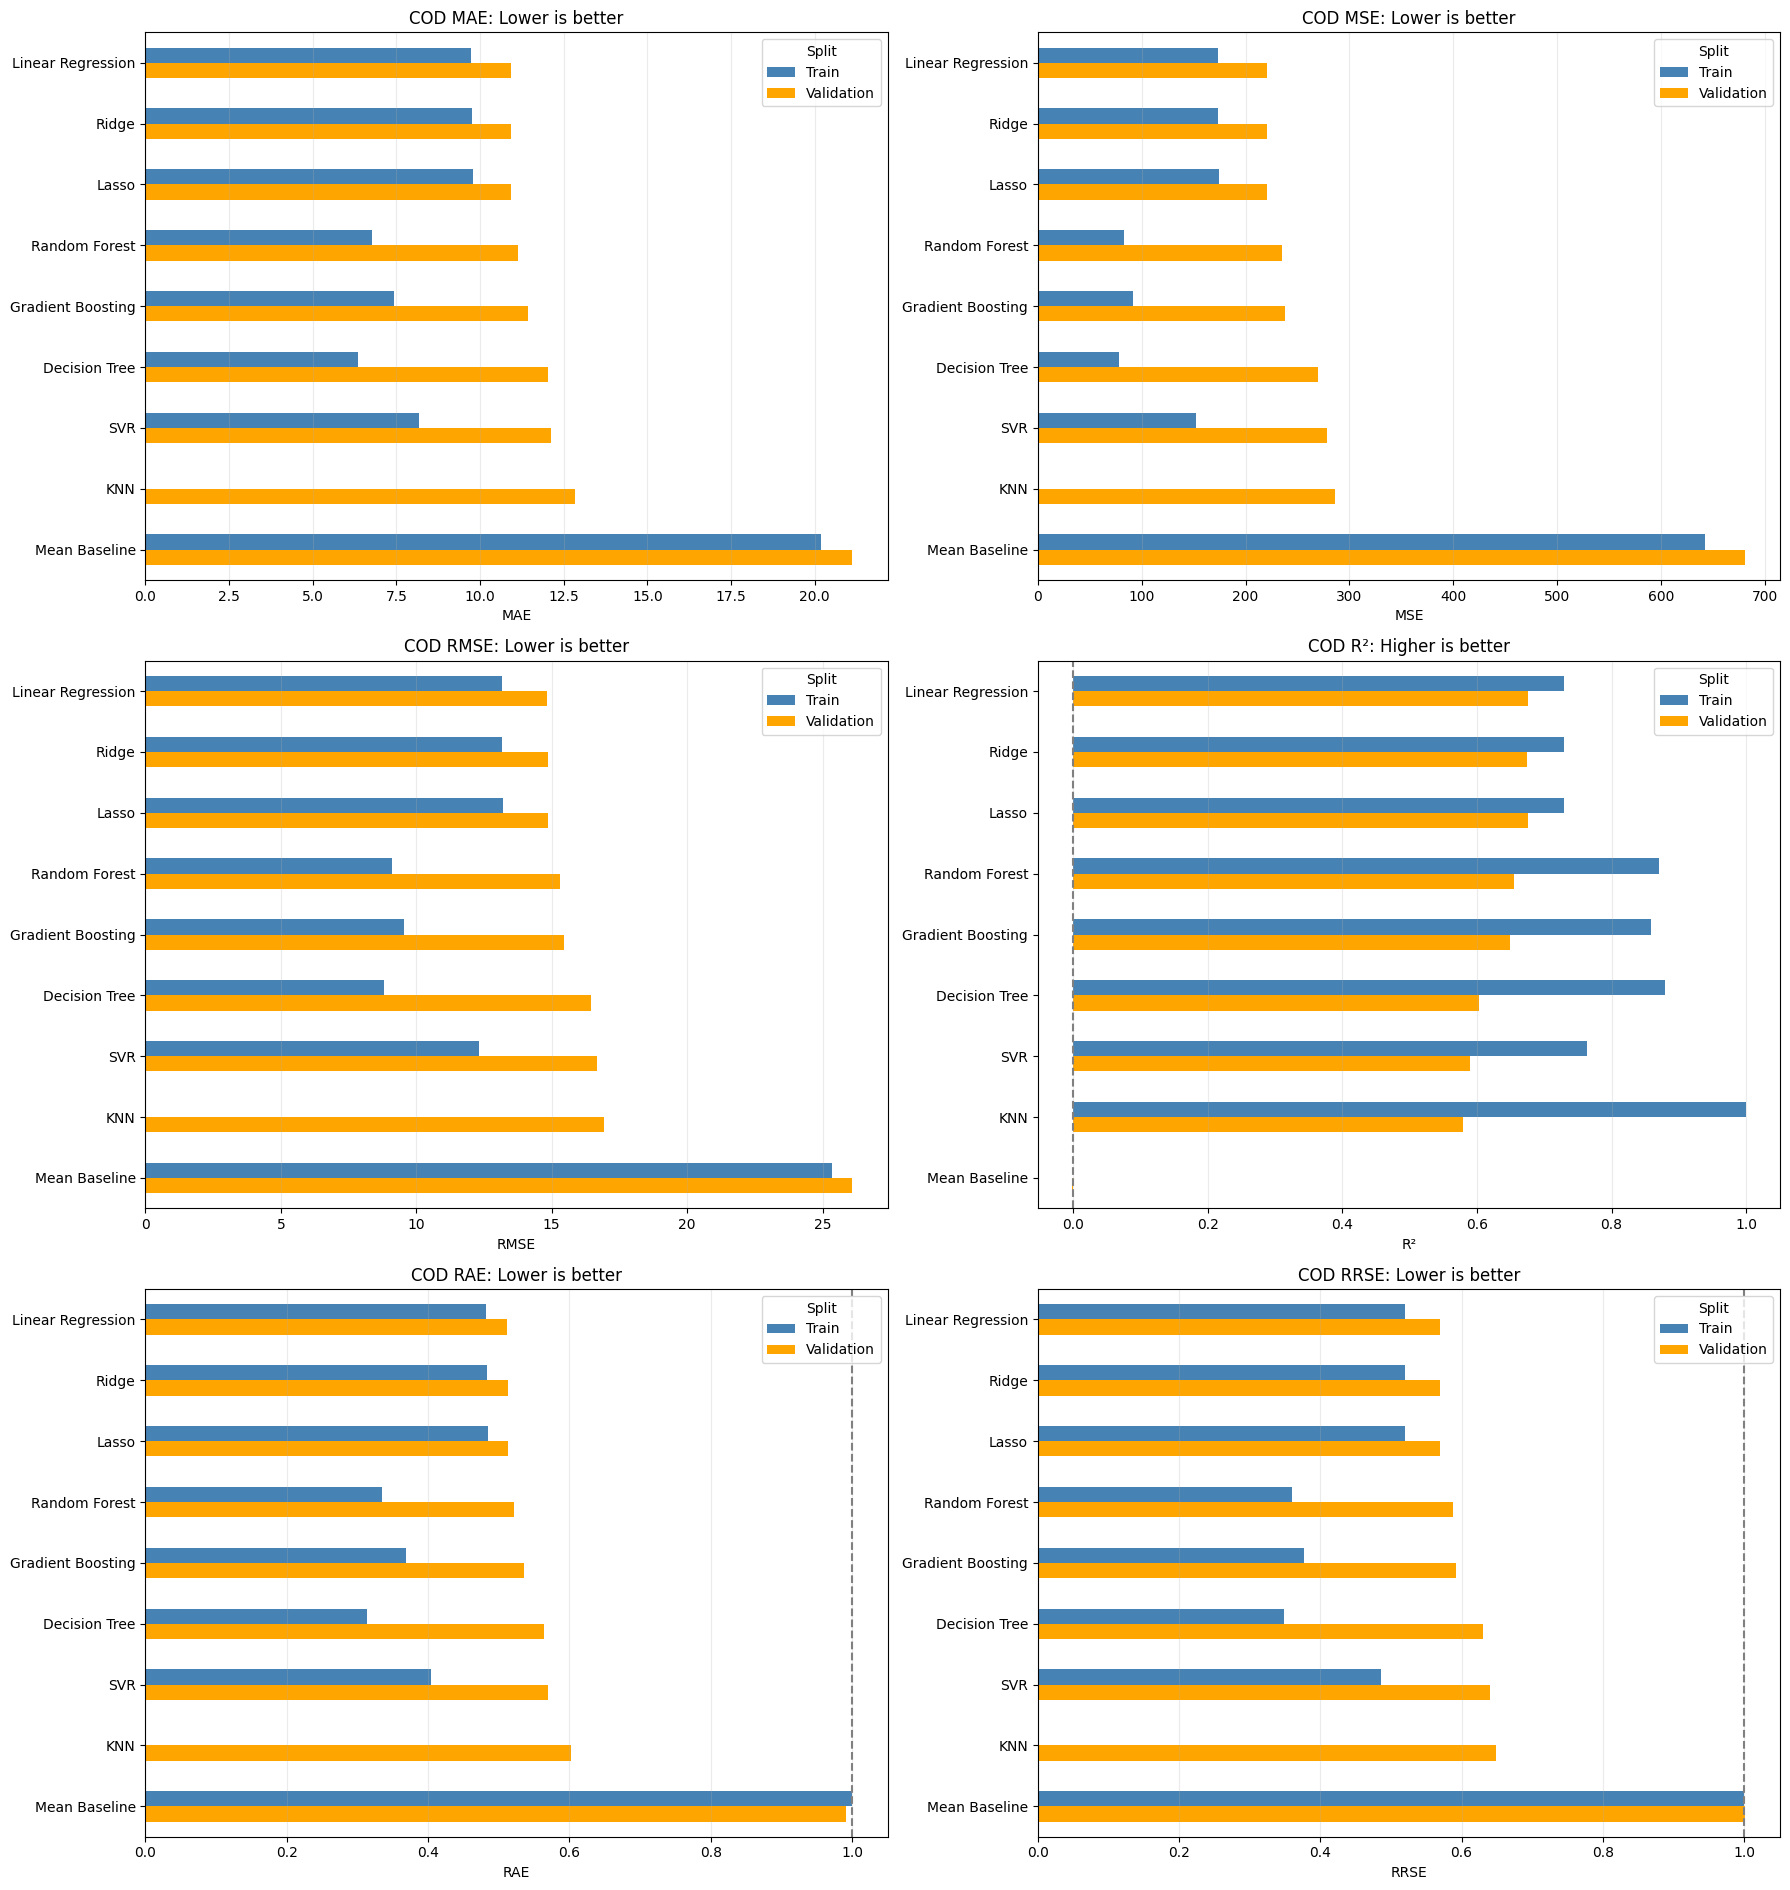

In [571]:
#plot all COD model comparisons


fig, axes = plt.subplots(3, 2, figsize=(18, 19))

for ax, metric in zip(
    axes.flat,
    ["MAE", "MSE", "RMSE", "R²", "RAE", "RRSE"]
):
    plot_data = (
        cod_metrics.pivot(
            index="Model",
            columns="Split",
            values=metric
        )
        .reindex(cod_model_order)[["Train", "Validation"]]
    )

    plot_data.plot.barh(
        ax=ax,
        color=["steelblue", "orange"]
    )

    ax.invert_yaxis()

    direction = (
        "Higher is better"
        if metric == "R²"
        else "Lower is better"
    )

    ax.set_title(f"COD {metric}: {direction}")
    ax.set_ylabel("")
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.25)

    if metric in ["RAE", "RRSE"]:
        ax.axvline(1, color="gray", linestyle="--")
    elif metric == "R²":
        ax.axvline(0, color="gray", linestyle="--")

plt.tight_layout()
plt.show()

inspect the selected COD model’s validation errors


In [572]:
#Select the COD candidate


cod_best_model_name = cod_validation_ranking.iloc[0]["Model"]

cod_best_model = cod_fitted_models[cod_best_model_name]

cod_actual = cod_y_validation.to_numpy(dtype=float)

cod_predicted = cod_predictions[
    cod_best_model_name
]["Validation"]

print("Selected COD candidate:", cod_best_model_name)

display(cod_validation_ranking.head(1).round(3))

Selected COD candidate: Linear Regression


,Model,Split,MAE,MSE,RMSE,R²,RAE,RRSE
0,Linear Regression,Validation,10.908,220.309,14.843,0.676,0.512,0.569


In [573]:
#Display training–validation gaps


cod_gap_table = cod_error_table.pivot(
    index="Model",
    columns="Split",
    values="MAE"
)

cod_gap_table["MAE_Gap"] = (
    cod_gap_table["Validation"]
    - cod_gap_table["Train"]
)

display(
    cod_gap_table.sort_values("Validation").round(3)
)

Split,Train,Validation,MAE_Gap
Model,,,
Linear Regression,9.740,10.908,1.167
Ridge,9.745,10.920,1.175
Lasso,9.788,10.922,1.134
Random Forest,6.764,11.128,4.364
Gradient Boosting,7.434,11.419,3.985
Decision Tree,6.338,12.013,5.676
SVR,8.160,12.129,3.969
KNN,0.000,12.822,12.822
Mean Baseline,20.191,21.116,0.925


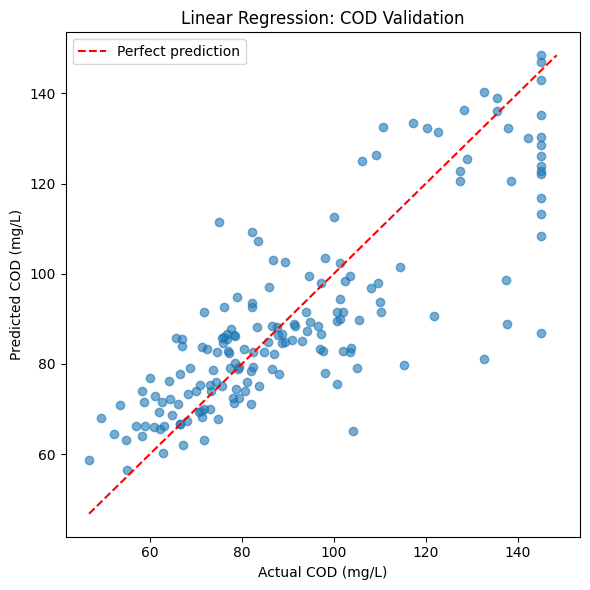

In [574]:
#Plot actual vs predicted COD



lower = min(cod_actual.min(), cod_predicted.min())
upper = max(cod_actual.max(), cod_predicted.max())

plt.figure(figsize=(6, 6))

plt.scatter(cod_actual, cod_predicted, alpha=0.6)

plt.plot(
    [lower, upper],
    [lower, upper],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual COD (mg/L)")
plt.ylabel("Predicted COD (mg/L)")
plt.title(f"{cod_best_model_name}: COD Validation")
plt.legend()
plt.tight_layout()
plt.show()

In [575]:
# Calculate errors by plant



cod_validation_errors = pd.DataFrame({
    "Plant": cod_X_validation["plant_id"].to_numpy(),
    "Actual": cod_actual,
    "Predicted": cod_predicted
})

cod_validation_errors["Residual"] = (
    cod_validation_errors["Actual"]
    - cod_validation_errors["Predicted"]
)

cod_validation_errors["Absolute_Error"] = (
    cod_validation_errors["Residual"].abs()
)

cod_plant_errors = (
    cod_validation_errors.groupby("Plant")
    .agg(
        Observations=("Absolute_Error", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(cod_plant_errors.round(3))

,Observations,MAE,Mean_Residual
Plant,,,
WWTP-02,34,17.316,4.200
WWTP-04,34,14.156,0.165
WWTP-05,34,9.286,3.073
WWTP-03,34,7.451,1.428
WWTP-01,34,6.329,-0.404


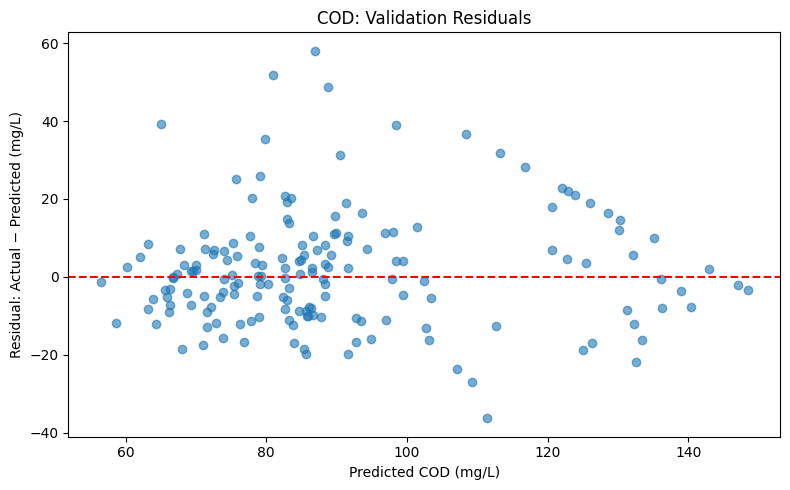

In [576]:
#Plot validation residuals

plt.figure(figsize=(8, 5))

plt.scatter(
    cod_validation_errors["Predicted"],
    cod_validation_errors["Residual"],
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted COD (mg/L)")
plt.ylabel("Residual: Actual − Predicted (mg/L)")
plt.title("COD: Validation Residuals")
plt.tight_layout()
plt.show()

final COD test evaluation

In [577]:
#Fix the selected model

from sklearn.base import clone
from sklearn.dummy import DummyRegressor

cod_selected_model_name = cod_best_model_name

cod_final_model = clone(
    cod_fitted_models[cod_selected_model_name]
)

print("Final COD model:", cod_selected_model_name)

Final COD model: Linear Regression


In [578]:
#Combine train and validation data

cod_X_development = pd.concat([
    cod_X_train,
    cod_X_validation
])

cod_y_development = pd.concat([
    cod_y_train,
    cod_y_validation
])

assert cod_X_development.index.equals(
    cod_y_development.index
)

assert cod_X_development.index.intersection(
    cod_X_test.index
).empty

print("Final fitting rows:", len(cod_X_development))
print("Test rows:", len(cod_X_test))

Final fitting rows: 675
Test rows: 169


In [579]:
#Fit the final pipeline and baseline

cod_final_model.fit(
    cod_X_development,
    cod_y_development
)

cod_test_predictions = cod_final_model.predict(
    cod_X_test
)

cod_final_baseline = DummyRegressor(strategy="mean")

cod_final_baseline.fit(
    cod_X_development,
    cod_y_development
)

cod_baseline_test_predictions = (
    cod_final_baseline.predict(cod_X_test)
)

In [580]:
#Calculate test metrics

cod_test_actual = cod_y_test.to_numpy(dtype=float)

cod_centered = (
    cod_test_actual - cod_test_actual.mean()
)

cod_absolute_denominator = np.abs(cod_centered).sum()
cod_squared_denominator = np.square(cod_centered).sum()

cod_test_rows = []

for name, predicted_values in [
    (cod_selected_model_name, cod_test_predictions),
    ("Mean Baseline", cod_baseline_test_predictions)
]:
    residuals = cod_test_actual - predicted_values

    mse = mean_squared_error(
        cod_test_actual,
        predicted_values
    )

    cod_test_rows.append({
        "Model": name,
        "Split": "Test",
        "MAE": mean_absolute_error(
            cod_test_actual, predicted_values
        ),
        "RMSE": np.sqrt(mse),
        "R²": (
            r2_score(cod_test_actual, predicted_values)
            if cod_squared_denominator > 0 else np.nan
        ),
        "RAE": (
            np.abs(residuals).sum()
            / cod_absolute_denominator
            if cod_absolute_denominator > 0 else np.nan
        ),
        "RRSE": (
            np.sqrt(
                np.square(residuals).sum()
                / cod_squared_denominator
            )
            if cod_squared_denominator > 0 else np.nan
        )
    })

cod_test_results = pd.DataFrame(cod_test_rows)

display(cod_test_results.round(3))

,Model,Split,MAE,RMSE,R²,RAE,RRSE
0,Linear Regression,Test,10.165,13.087,0.671,0.554,0.573
1,Mean Baseline,Test,18.327,22.821,-0.000,0.999,1.000


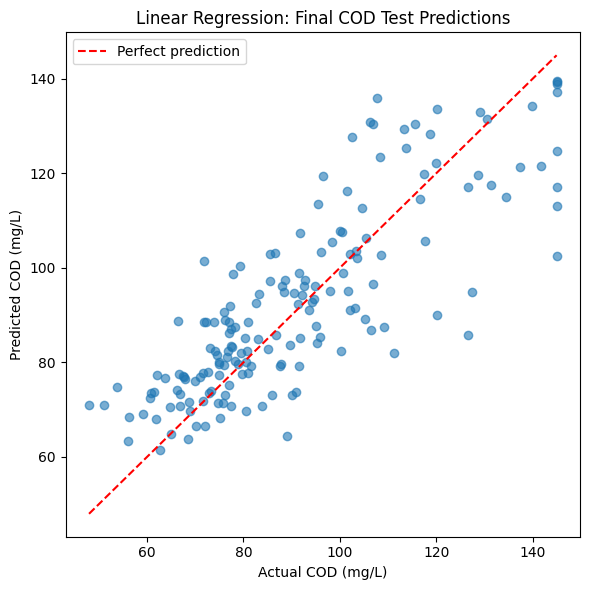

In [581]:
#Plot final COD test predictions

lower = min(
    cod_test_actual.min(),
    cod_test_predictions.min()
)

upper = max(
    cod_test_actual.max(),
    cod_test_predictions.max()
)

plt.figure(figsize=(6, 6))

plt.scatter(
    cod_test_actual,
    cod_test_predictions,
    alpha=0.6
)

plt.plot(
    [lower, upper],
    [lower, upper],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual COD (mg/L)")
plt.ylabel("Predicted COD (mg/L)")
plt.title("Linear Regression: Final COD Test Predictions")
plt.legend()
plt.tight_layout()
plt.show()



In [582]:
#Calculate how much the selected model improved over the baseline

cod_model_mae = cod_test_results.loc[
    cod_test_results["Model"] == cod_selected_model_name, "MAE"
].iloc[0]

cod_baseline_mae = cod_test_results.loc[
    cod_test_results["Model"] == "Mean Baseline", "MAE"
].iloc[0]

if cod_baseline_mae > 0:
    cod_improvement_pct = (
        (cod_baseline_mae - cod_model_mae) / cod_baseline_mae
    ) * 100

    print(f"Selected COD model: {cod_selected_model_name}")
    print(f"Model test MAE: {cod_model_mae:.3f} mg/L")
    print(f"Baseline test MAE: {cod_baseline_mae:.3f} mg/L")
    print(f"MAE reduction: {cod_improvement_pct:.2f}%")
else:
    print("Percentage improvement is undefined because baseline MAE is zero.")

Selected COD model: Linear Regression
Model test MAE: 10.165 mg/L
Baseline test MAE: 18.327 mg/L
MAE reduction: 44.54%


In [583]:
#Create a table containing every test prediction

cod_test_prediction_table = data.loc[
    cod_X_test.index,
    ["record_id", "plant_id", "observation_date"]
].copy()

cod_test_prediction_table["Actual_COD"] = cod_test_actual
cod_test_prediction_table["Predicted_COD"] = cod_test_predictions

cod_test_prediction_table["Residual"] = (
    cod_test_prediction_table["Actual_COD"]
    - cod_test_prediction_table["Predicted_COD"]
)

cod_test_prediction_table["Absolute_Error"] = (
    cod_test_prediction_table["Residual"].abs()
)

display(cod_test_prediction_table.head(10))

,record_id,plant_id,observation_date,Actual_COD,Predicted_COD,Residual,Absolute_Error
680,WQ-0681,WWTP-01,2024-05-16,95.05,87.664734,7.385266,7.385266
681,WQ-0682,WWTP-02,2024-05-16,71.84,88.571017,-16.731017,16.731017
682,WQ-0683,WWTP-03,2024-05-16,79.59,81.921208,-2.331208,2.331208
683,WQ-0684,WWTP-04,2024-05-16,145.00,137.270230,7.729770,7.729770
684,WQ-0685,WWTP-05,2024-05-16,82.65,92.491616,-9.841616,9.841616
685,WQ-0686,WWTP-01,2024-05-17,67.77,76.940795,-9.170795,9.170795
686,WQ-0687,WWTP-02,2024-05-17,105.23,89.120791,16.109209,16.109209
687,WQ-0688,WWTP-03,2024-05-17,67.50,77.164546,-9.664546,9.664546
688,WQ-0689,WWTP-04,2024-05-17,145.00,138.842519,6.157481,6.157481
689,WQ-0690,WWTP-05,2024-05-17,77.36,87.052199,-9.692199,9.692199


In [584]:
#Compare test errors across plants

cod_test_plant_results = (
    cod_test_prediction_table
    .groupby("plant_id")
    .agg(
        Test_Rows=("Absolute_Error", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(cod_test_plant_results.round(3))

,Test_Rows,MAE,Mean_Residual
plant_id,,,
WWTP-02,33,14.770,4.351
WWTP-04,34,13.492,-4.109
WWTP-05,34,9.783,-3.600
WWTP-01,34,6.655,-1.271
WWTP-03,34,6.260,-2.356


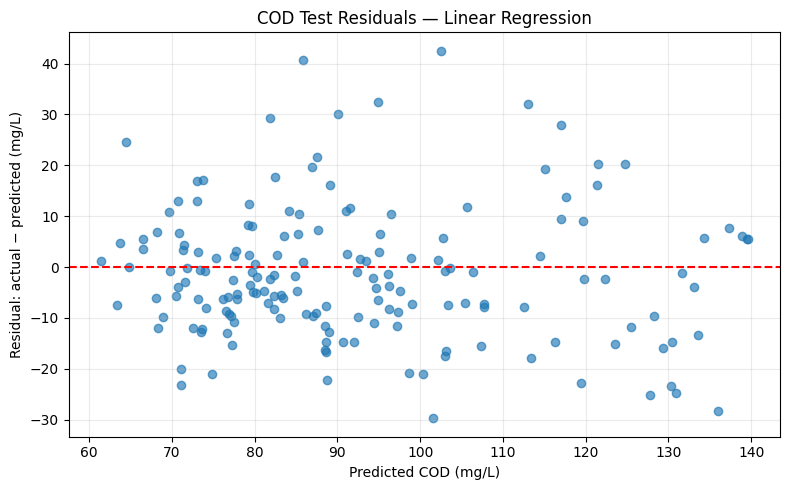

In [585]:
#4. Plot the COD test residuals


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    cod_test_prediction_table["Predicted_COD"],
    cod_test_prediction_table["Residual"],
    alpha=0.65
)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted COD (mg/L)")
plt.ylabel("Residual: actual − predicted (mg/L)")
plt.title(f"COD Test Residuals — {cod_selected_model_name}")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [586]:
#Save the model and result tables

from pathlib import Path
import joblib

cod_output_dir = Path("cod_results")
cod_output_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "pipeline": cod_final_model,
        "target": cod_target,
        "feature_columns": cod_X_development.columns.tolist(),
        "selection_metric": "Validation MAE",
        "model_name": cod_selected_model_name
    },
    cod_output_dir / "cod_pipeline.joblib"
)

cod_test_results.to_csv(
    cod_output_dir / "cod_test_metrics.csv",
    index=False
)

cod_test_prediction_table.to_csv(
    cod_output_dir / "cod_test_predictions.csv",
    index=False
)

cod_test_plant_results.to_csv(
    cod_output_dir / "cod_test_metrics_by_plant.csv"
)

cod_error_table.to_csv(
    cod_output_dir / "cod_training_validation_errors.csv",
    index=False
)

cod_relative_table.to_csv(
    cod_output_dir / "cod_training_validation_relative_metrics.csv",
    index=False
)

print("COD model and result tables saved successfully.")
print("Saved folder:", cod_output_dir.resolve())

COD model and result tables saved successfully.
Saved folder: /content/cod_results


In [587]:
import shutil
from google.colab import files

cod_zip_path = shutil.make_archive(
    "/content/cod_results_backup",
    "zip",
    root_dir="/content",
    base_dir="cod_results"
)

files.download(cod_zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **TSS**

In [588]:
#Display the definitions of BOD, COD and TSS


from pathlib import Path
import pandas as pd
import numpy as np

workbook_matches = list(
    Path("/content").glob("Wastewater_Effluent_and_Critical_Minerals*.xlsx")
)

if len(workbook_matches) != 1:
    raise ValueError(
        "Keep exactly one project workbook in /content before running this cell."
    )

project_workbook = workbook_matches[0]

project_dictionary = pd.read_excel(
    project_workbook,
    sheet_name="Data Dictionary"
)

display(
    project_dictionary.loc[
        project_dictionary["Column"].isin([
            "observation_date",
            "effluent_bod_mg_l",
            "effluent_cod_mg_l",
            "effluent_tss_mg_l"
        ]),
        ["Column", "Role", "Description", "Unit/type"]
    ]
)

,Column,Role,Description,Unit/type
1,observation_date,Neither,Date of plant observation,Date
27,effluent_bod_mg_l,Output,Next-day effluent BOD,mg/L
28,effluent_cod_mg_l,Output,Next-day effluent COD,mg/L
29,effluent_tss_mg_l,Output,Next-day effluent TSS,mg/L


In [589]:
#Check that our existing inputs exclude effluent outputs


missing_features = [
    column for column in candidate_feature
    if column not in data.columns
]

output_features = [
    column for column in candidate_feature
    if column.startswith("effluent_")
]

assert not missing_features, f"Missing columns: {missing_features}"
assert not output_features, f"Output columns used as inputs: {output_features}"

print("Current input count:", len(candidate_feature))
display(pd.DataFrame({"Current_Input": candidate_feature}))

Current input count: 17


,Current_Input
0,influent_flow_m3_day
1,influent_temperature_c
2,influent_ph
3,influent_bod_mg_l
4,influent_cod_mg_l
5,influent_tss_mg_l
6,influent_total_nitrogen_mg_l
7,influent_total_phosphorus_mg_l
8,influent_conductivity_us_cm
9,influent_lithium_ug_l


In [590]:
#Prepare the TSS inputs and target

tss_target = "effluent_tss_mg_l"

tss_valid_mask = data[tss_target].notna()

tss_X = data.loc[
    tss_valid_mask, candidate_feature
].copy()

tss_y = data.loc[
    tss_valid_mask, tss_target
].copy()

tss_dates = pd.to_datetime(
    data.loc[tss_valid_mask, "observation_date"]
)

assert tss_X.index.equals(tss_y.index)

print("Rows with known TSS:", len(tss_y))
print("Rows excluded because TSS is missing:", (~tss_valid_mask).sum())
print("Number of inputs:", tss_X.shape[1])

Rows with known TSS: 848
Rows excluded because TSS is missing: 2
Number of inputs: 17


In [591]:
#Apply the same chronological split boundaries


tss_train_mask = tss_dates < validation_start

tss_validation_mask = (
    (tss_dates >= validation_start)
    & (tss_dates < test_start)
)

tss_test_mask = tss_dates >= test_start

tss_X_train = tss_X.loc[tss_train_mask].copy()
tss_y_train = tss_y.loc[tss_train_mask].copy()

tss_X_validation = tss_X.loc[tss_validation_mask].copy()
tss_y_validation = tss_y.loc[tss_validation_mask].copy()

tss_X_test = tss_X.loc[tss_test_mask].copy()
tss_y_test = tss_y.loc[tss_test_mask].copy()

In [592]:
#Verify the split and display its dates

tss_split_rows = []

for split_name, split_X, split_y in [
    ("Train", tss_X_train, tss_y_train),
    ("Validation", tss_X_validation, tss_y_validation),
    ("Test", tss_X_test, tss_y_test)
]:
    assert split_X.index.equals(split_y.index)
    assert len(split_y) > 0

    split_dates = tss_dates.loc[split_X.index]

    tss_split_rows.append({
        "Split": split_name,
        "Rows": len(split_y),
        "First_Observation": split_dates.min(),
        "Last_Observation": split_dates.max()
    })

assert tss_X_train.index.intersection(tss_X_validation.index).empty
assert tss_X_train.index.intersection(tss_X_test.index).empty
assert tss_X_validation.index.intersection(tss_X_test.index).empty

assert (
    tss_dates.loc[tss_X_train.index].max()
    < tss_dates.loc[tss_X_validation.index].min()
)

assert (
    tss_dates.loc[tss_X_validation.index].max()
    < tss_dates.loc[tss_X_test.index].min()
)

display(pd.DataFrame(tss_split_rows))
print("TSS split checks passed.")

,Split,Rows,First_Observation,Last_Observation
0,Train,509,2024-01-01,2024-04-11
1,Validation,169,2024-04-12,2024-05-15
2,Test,170,2024-05-16,2024-06-18


TSS split checks passed.


In [593]:
#Create one reusable function for calculating metrics

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float).reshape(-1)
    predicted = np.asarray(predicted, dtype=float).reshape(-1)

    if actual.shape != predicted.shape:
        raise ValueError("Actual and predicted values must have matching shapes.")

    residuals = actual - predicted
    centered = actual - actual.mean()

    mse = mean_squared_error(actual, predicted)
    absolute_denominator = np.abs(centered).sum()
    squared_denominator = np.square(centered).sum()

    return {
        "MAE": mean_absolute_error(actual, predicted),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": (
            r2_score(actual, predicted)
            if squared_denominator > 0 else np.nan
        ),
        "RAE": (
            np.abs(residuals).sum() / absolute_denominator
            if absolute_denominator > 0 else np.nan
        ),
        "RRSE": (
            np.sqrt(
                np.square(residuals).sum() / squared_denominator
            )
            if squared_denominator > 0 else np.nan
        )
    }

In [594]:
#Create one reusable model-comparison function


def compare_regression_models(
    model_definitions,
    preprocessing,
    X_train,
    y_train,
    X_validation,
    y_validation
):
    assert X_train.index.equals(y_train.index)
    assert X_validation.index.equals(y_validation.index)
    assert X_train.columns.equals(X_validation.columns)

    fitted = {}
    cached_predictions = {}
    metric_rows = []

    for model_name, estimator in model_definitions.items():
        model_pipeline = Pipeline([
            ("preprocessing", clone(preprocessing)),
            ("model", clone(estimator))
        ])

        model_pipeline.fit(X_train, y_train)

        fitted[model_name] = model_pipeline
        cached_predictions[model_name] = {}

        for split_name, inputs, actual in [
            ("Train", X_train, y_train),
            ("Validation", X_validation, y_validation)
        ]:
            predicted = model_pipeline.predict(inputs)

            cached_predictions[model_name][split_name] = predicted

            metric_rows.append({
                "Model": model_name,
                "Split": split_name,
                **calculate_regression_metrics(actual, predicted)
            })

    metrics = pd.DataFrame(metric_rows)

    validation_ranking = (
        metrics.loc[metrics["Split"].eq("Validation")]
        .sort_values("MAE", kind="stable")
        .reset_index(drop=True)
    )

    model_order = validation_ranking["Model"].tolist()

    ordered_metrics = (
        metrics.assign(
            Model_Order=metrics["Model"].map({
                name: position
                for position, name in enumerate(model_order)
            }),
            Split_Order=metrics["Split"].map({
                "Train": 0,
                "Validation": 1
            })
        )
        .sort_values(["Model_Order", "Split_Order"])
        .drop(columns=["Model_Order", "Split_Order"])
        .reset_index(drop=True)
    )

    return {
        "fitted_models": fitted,
        "predictions": cached_predictions,
        "metrics": ordered_metrics,
        "validation_ranking": validation_ranking,
        "model_order": model_order
    }

In [595]:
#Run the comparison for TSS


tss_comparison = compare_regression_models(
    model_definitions=models,
    preprocessing=preprocessor,
    X_train=tss_X_train,
    y_train=tss_y_train,
    X_validation=tss_X_validation,
    y_validation=tss_y_validation
)

tss_fitted_models = tss_comparison["fitted_models"]
tss_predictions = tss_comparison["predictions"]
tss_metrics = tss_comparison["metrics"]
tss_validation_ranking = tss_comparison["validation_ranking"]
tss_model_order = tss_comparison["model_order"]

print(f"Completed comparison for {len(tss_fitted_models)} models.")

Completed comparison for 9 models.


In [596]:
#Display the first table: MAE, MSE and RMSE

tss_error_table = tss_metrics[
    ["Model", "Split", "MAE", "MSE", "RMSE"]
].copy()

display(tss_error_table.round(3))

,Model,Split,MAE,MSE,RMSE
0,Lasso,Train,3.811,25.473,5.047
1,Lasso,Validation,4.206,32.077,5.664
2,Gradient Boosting,Train,2.891,13.146,3.626
3,Gradient Boosting,Validation,4.254,36.818,6.068
4,Ridge,Train,3.784,25.021,5.002
5,Ridge,Validation,4.312,32.868,5.733
6,Linear Regression,Train,3.785,25.020,5.002
7,Linear Regression,Validation,4.313,32.837,5.730
8,Random Forest,Train,2.581,11.990,3.463
9,Random Forest,Validation,4.362,35.221,5.935


In [597]:
#Display the second table and the validation ranking

tss_relative_table = tss_metrics[
    ["Model", "Split", "R²", "RAE", "RRSE"]
].copy()

print("TSS relative metrics:")
display(tss_relative_table.round(3))

print("TSS models ranked by validation MAE:")
display(
    tss_validation_ranking[
        ["Model", "MAE", "RMSE", "R²", "RAE", "RRSE"]
    ].round(3)
)

tss_best_model_name = tss_validation_ranking.iloc[0]["Model"]

print("Lowest validation-MAE model:", tss_best_model_name)

TSS relative metrics:


,Model,Split,R²,RAE,RRSE
0,Lasso,Train,0.573,0.664,0.653
1,Lasso,Validation,0.492,0.719,0.713
2,Gradient Boosting,Train,0.780,0.504,0.469
3,Gradient Boosting,Validation,0.416,0.728,0.764
4,Ridge,Train,0.581,0.659,0.648
5,Ridge,Validation,0.479,0.738,0.722
6,Linear Regression,Train,0.581,0.659,0.648
7,Linear Regression,Validation,0.480,0.738,0.721
8,Random Forest,Train,0.799,0.450,0.448
9,Random Forest,Validation,0.442,0.746,0.747


TSS models ranked by validation MAE:


,Model,MAE,RMSE,R²,RAE,RRSE
0,Lasso,4.206,5.664,0.492,0.719,0.713
1,Gradient Boosting,4.254,6.068,0.416,0.728,0.764
2,Ridge,4.312,5.733,0.479,0.738,0.722
3,Linear Regression,4.313,5.730,0.480,0.738,0.721
4,Random Forest,4.362,5.935,0.442,0.746,0.747
5,SVR,4.376,5.964,0.436,0.748,0.751
6,KNN,4.582,6.079,0.414,0.784,0.765
7,Decision Tree,5.452,7.227,0.172,0.933,0.910
8,Mean Baseline,5.891,7.945,-0.000,1.008,1.000


Lowest validation-MAE model: Lasso


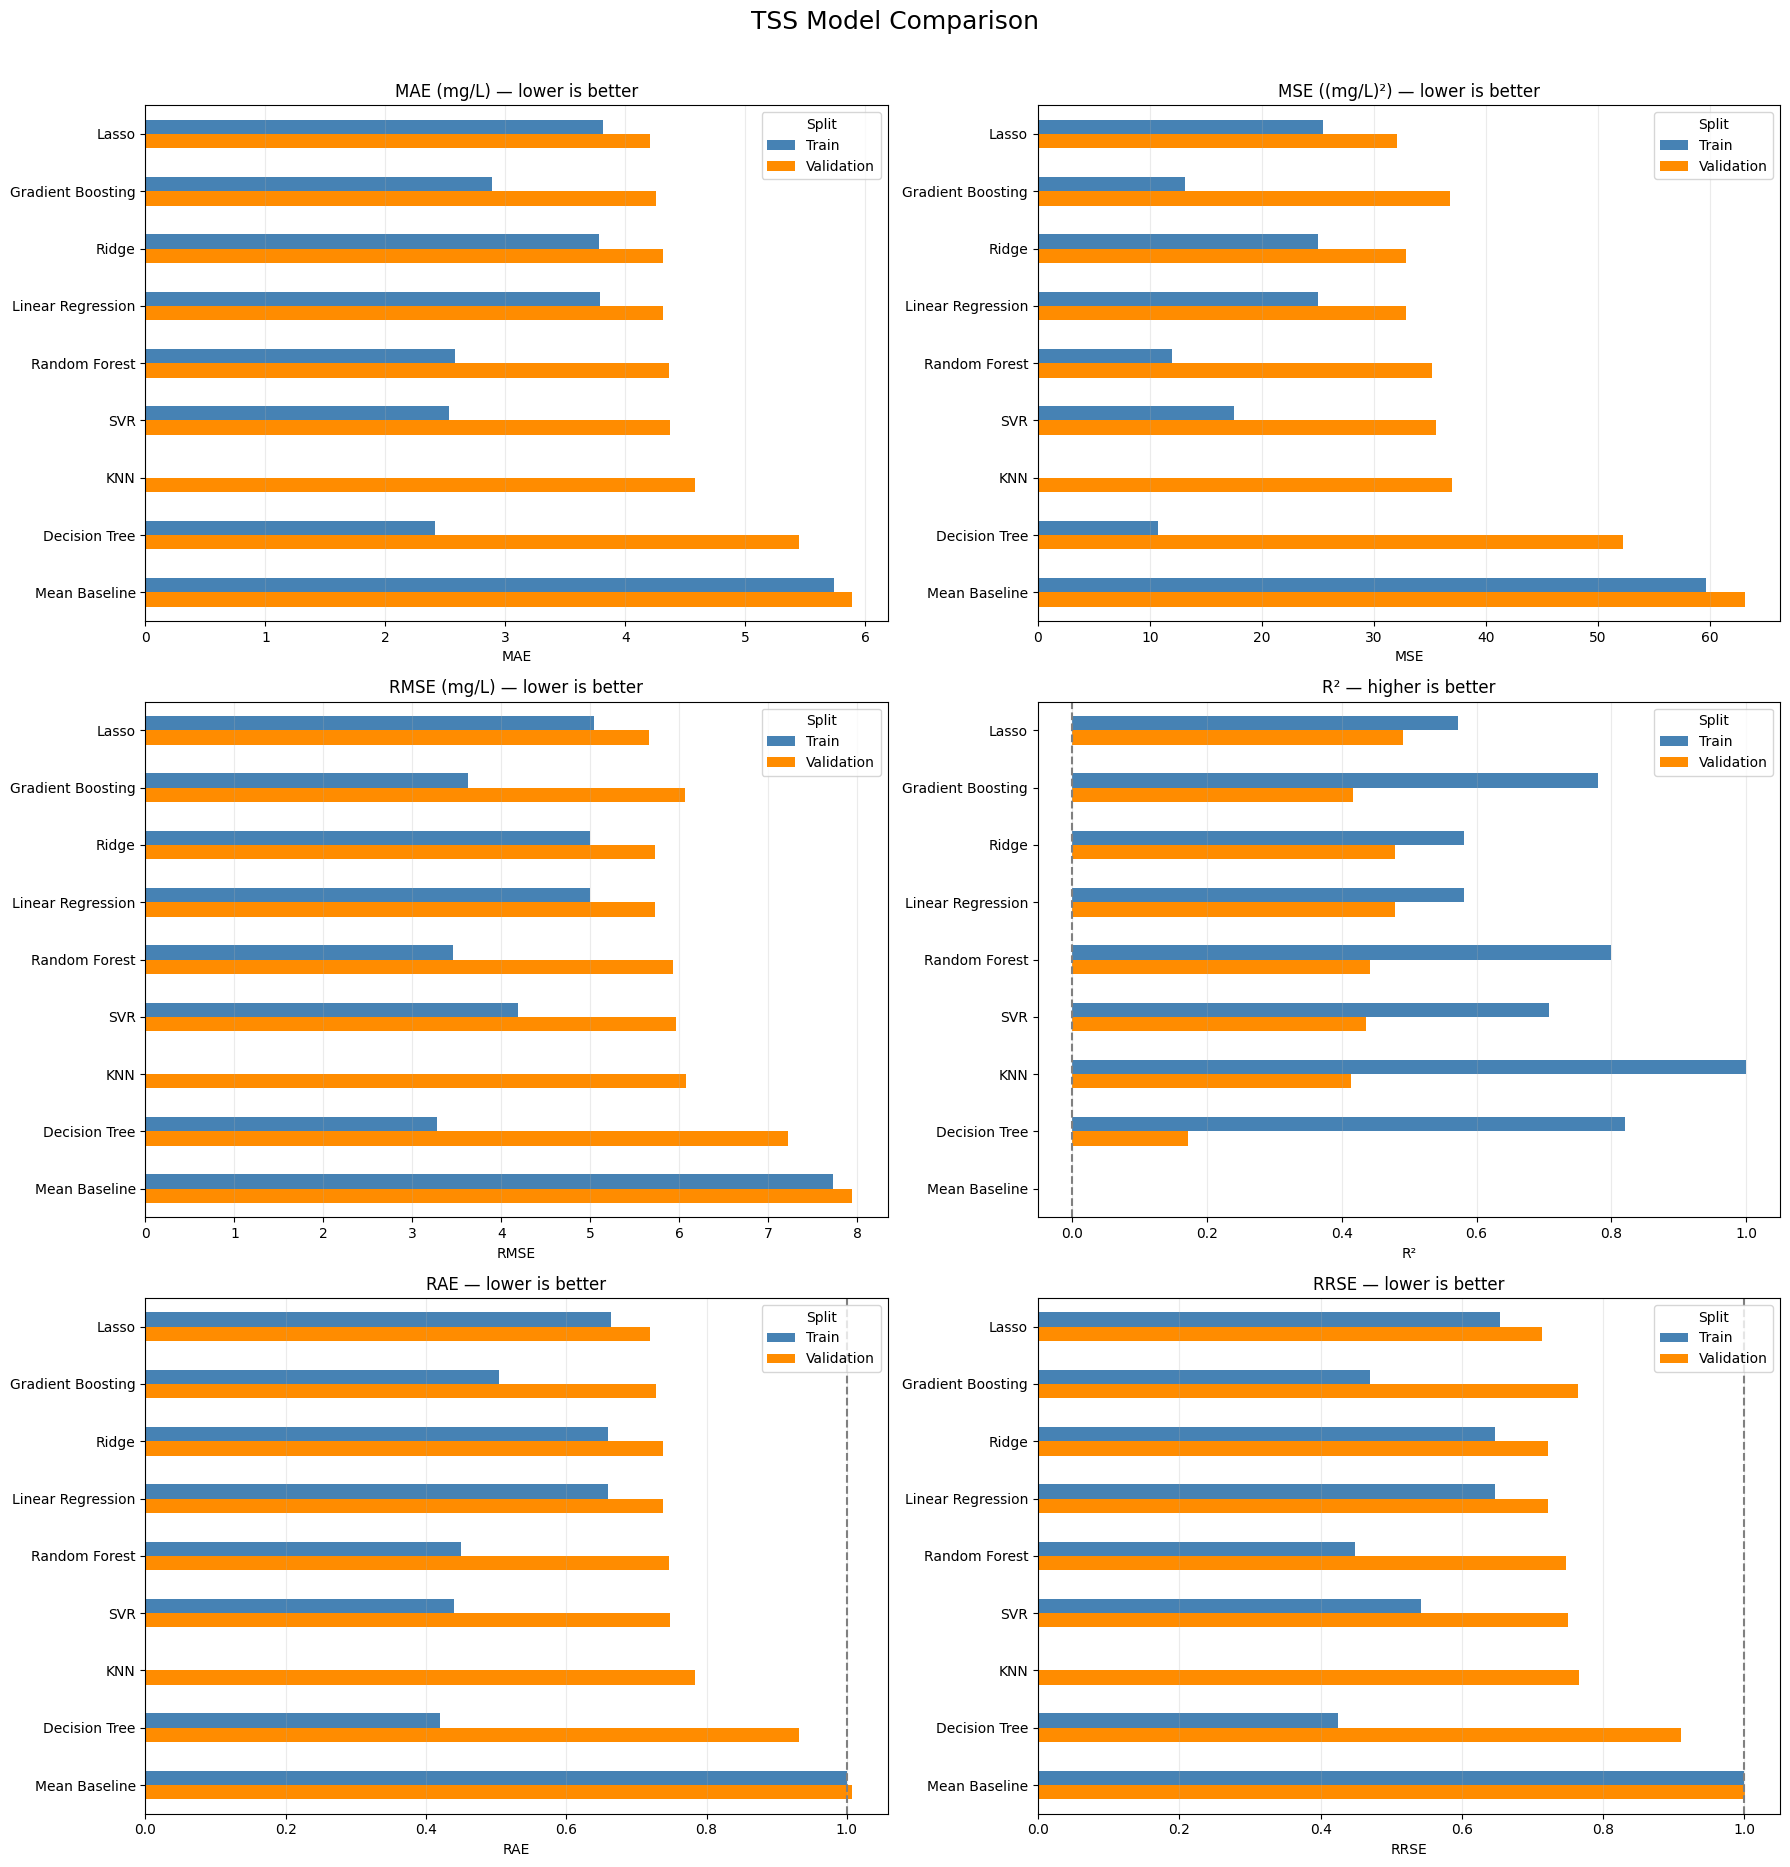

In [598]:
#Plot all six comparison metrics


import matplotlib.pyplot as plt

plot_settings = [
    ("MAE", "MAE (mg/L) — lower is better"),
    ("MSE", "MSE ((mg/L)²) — lower is better"),
    ("RMSE", "RMSE (mg/L) — lower is better"),
    ("R²", "R² — higher is better"),
    ("RAE", "RAE — lower is better"),
    ("RRSE", "RRSE — lower is better")
]

fig, axes = plt.subplots(3, 2, figsize=(18, 19))

for ax, (metric, title) in zip(axes.flat, plot_settings):
    plot_table = (
        tss_metrics
        .pivot(index="Model", columns="Split", values=metric)
        .reindex(tss_model_order)
        [["Train", "Validation"]]
    )

    plot_table.plot(
        kind="barh",
        ax=ax,
        color=["steelblue", "darkorange"]
    )

    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(title="Split")

    if metric == "R²":
        ax.axvline(0, color="gray", linestyle="--")
    elif metric in ["RAE", "RRSE"]:
        ax.axvline(1, color="gray", linestyle="--")

fig.suptitle("TSS Model Comparison", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [599]:
#Display the training–validation MAE gap

tss_gap_table = (
    tss_metrics
    .pivot(index="Model", columns="Split", values="MAE")
    .reindex(tss_model_order)
    [["Train", "Validation"]]
)

tss_gap_table["MAE_Gap"] = (
    tss_gap_table["Validation"] - tss_gap_table["Train"]
)

display(tss_gap_table.round(3))

Split,Train,Validation,MAE_Gap
Model,,,
Lasso,3.811,4.206,0.395
Gradient Boosting,2.891,4.254,1.363
Ridge,3.784,4.312,0.528
Linear Regression,3.785,4.313,0.528
Random Forest,2.581,4.362,1.780
SVR,2.529,4.376,1.847
KNN,0.000,4.582,4.582
Decision Tree,2.415,5.452,3.037
Mean Baseline,5.741,5.891,0.150


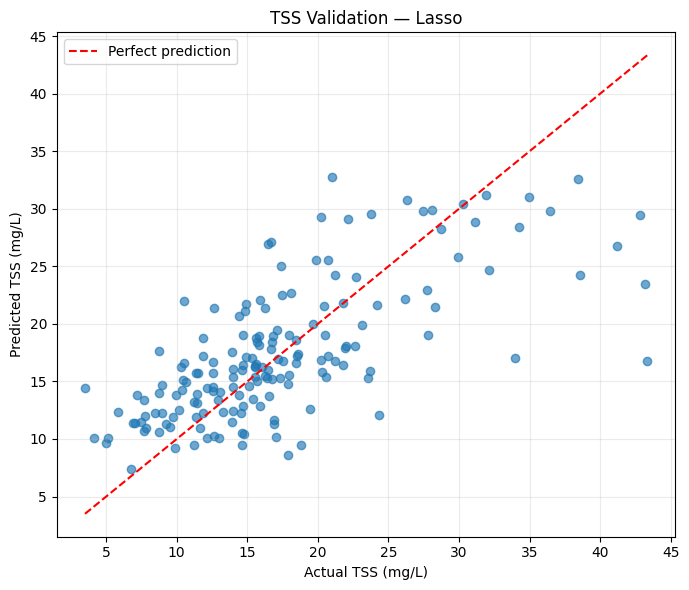

In [600]:
#Plot actual versus predicted TSS for Lasso

tss_best_model = tss_fitted_models[tss_best_model_name]

tss_validation_actual = tss_y_validation.to_numpy(dtype=float)

tss_validation_predicted = tss_predictions[
    tss_best_model_name
]["Validation"]

tss_plot_min = min(
    tss_validation_actual.min(),
    tss_validation_predicted.min()
)

tss_plot_max = max(
    tss_validation_actual.max(),
    tss_validation_predicted.max()
)

plt.figure(figsize=(7, 6))

plt.scatter(
    tss_validation_actual,
    tss_validation_predicted,
    alpha=0.65
)

plt.plot(
    [tss_plot_min, tss_plot_max],
    [tss_plot_min, tss_plot_max],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual TSS (mg/L)")
plt.ylabel("Predicted TSS (mg/L)")
plt.title(f"TSS Validation — {tss_best_model_name}")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [601]:
#Create the individual-error table and plant summary


tss_validation_errors = data.loc[
    tss_X_validation.index,
    ["record_id", "plant_id", "observation_date"]
].copy()

tss_validation_errors["Actual_TSS"] = tss_validation_actual
tss_validation_errors["Predicted_TSS"] = tss_validation_predicted

tss_validation_errors["Residual"] = (
    tss_validation_errors["Actual_TSS"]
    - tss_validation_errors["Predicted_TSS"]
)

tss_validation_errors["Absolute_Error"] = (
    tss_validation_errors["Residual"].abs()
)

tss_plant_errors = (
    tss_validation_errors
    .groupby("plant_id")
    .agg(
        Validation_Rows=("Absolute_Error", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

print("Individual validation predictions:")
display(tss_validation_errors.head(10))

print("Validation errors by plant:")
display(tss_plant_errors.round(3))

Individual validation predictions:


,record_id,plant_id,observation_date,Actual_TSS,Predicted_TSS,Residual,Absolute_Error
510,WQ-0511,WWTP-01,2024-04-12,17.95,19.017567,-1.067567,1.067567
511,WQ-0512,WWTP-02,2024-04-12,17.32,15.278874,2.041126,2.041126
512,WQ-0513,WWTP-03,2024-04-12,10.16,12.526511,-2.366511,2.366511
513,WQ-0514,WWTP-04,2024-04-12,14.84,21.114141,-6.274141,6.274141
514,WQ-0515,WWTP-05,2024-04-12,13.00,10.087319,2.912681,2.912681
515,WQ-0516,WWTP-01,2024-04-13,12.59,15.748650,-3.158650,3.158650
516,WQ-0517,WWTP-02,2024-04-13,10.38,14.240397,-3.860397,3.860397
517,WQ-0518,WWTP-03,2024-04-13,7.68,13.366980,-5.686980,5.686980
518,WQ-0519,WWTP-04,2024-04-13,20.70,25.542133,-4.842133,4.842133
519,WQ-0520,WWTP-05,2024-04-13,21.81,16.458435,5.351565,5.351565


Validation errors by plant:


,Validation_Rows,MAE,Mean_Residual
plant_id,,,
WWTP-04,34,5.704,-0.560
WWTP-02,34,5.267,1.088
WWTP-05,34,3.748,0.024
WWTP-01,33,3.518,-0.975
WWTP-03,34,2.773,-0.269


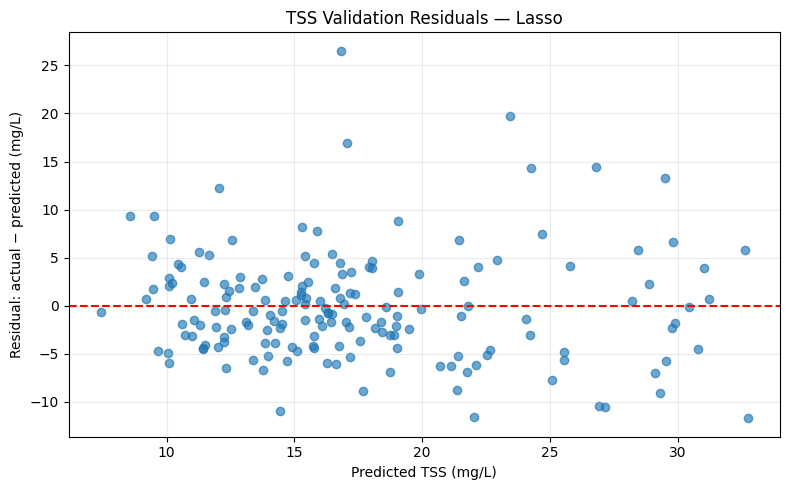

In [602]:
#Plot validation residuals




plt.figure(figsize=(8, 5))

plt.scatter(
    tss_validation_errors["Predicted_TSS"],
    tss_validation_errors["Residual"],
    alpha=0.65
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted TSS (mg/L)")
plt.ylabel("Residual: actual − predicted (mg/L)")
plt.title(f"TSS Validation Residuals — {tss_best_model_name}")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [603]:
#Refit the selected model using training plus validation data


from sklearn.base import clone

tss_selected_model_name = tss_best_model_name

tss_X_development = pd.concat([
    tss_X_train,
    tss_X_validation
])

tss_y_development = pd.concat([
    tss_y_train,
    tss_y_validation
])

assert tss_X_development.index.equals(tss_y_development.index)
assert tss_X_development.index.intersection(tss_X_test.index).empty

tss_final_model = clone(
    tss_fitted_models[tss_selected_model_name]
)

tss_final_model.fit(
    tss_X_development,
    tss_y_development
)

print("Selected model:", tss_selected_model_name)
print("Development rows:", len(tss_y_development))
print("Reserved test rows:", len(tss_y_test))

Selected model: Lasso
Development rows: 678
Reserved test rows: 170


In [604]:
#Generate test predictions and fit the reference baseline

from sklearn.dummy import DummyRegressor

tss_test_actual = tss_y_test.to_numpy(dtype=float)

tss_test_predictions = tss_final_model.predict(
    tss_X_test
)

tss_final_baseline = DummyRegressor(strategy="mean")

tss_final_baseline.fit(
    tss_X_development,
    tss_y_development
)

tss_baseline_test_predictions = tss_final_baseline.predict(
    tss_X_test
)

print("Test predictions generated:", len(tss_test_predictions))

Test predictions generated: 170


In [605]:
#Create the final test metrics table


tss_test_rows = []

for model_name, predicted in [
    (tss_selected_model_name, tss_test_predictions),
    ("Mean Baseline", tss_baseline_test_predictions)
]:
    tss_test_rows.append({
        "Model": model_name,
        "Split": "Test",
        **calculate_regression_metrics(
            tss_test_actual,
            predicted
        )
    })

tss_test_results = pd.DataFrame(tss_test_rows)

display(tss_test_results.round(3))

,Model,Split,MAE,MSE,RMSE,R²,RAE,RRSE
0,Lasso,Test,3.919,24.514,4.951,0.446,0.745,0.744
1,Mean Baseline,Test,5.324,44.486,6.670,-0.005,1.013,1.003


In [606]:
#Calculate the test MAE reduction



tss_model_mae = tss_test_results.loc[
    tss_test_results["Model"].eq(tss_selected_model_name),
    "MAE"
].iloc[0]

tss_baseline_mae = tss_test_results.loc[
    tss_test_results["Model"].eq("Mean Baseline"),
    "MAE"
].iloc[0]

print(f"Selected TSS model: {tss_selected_model_name}")
print(f"Model test MAE: {tss_model_mae:.3f} mg/L")
print(f"Baseline test MAE: {tss_baseline_mae:.3f} mg/L")

if tss_baseline_mae > 0:
    tss_improvement_pct = (
        (tss_baseline_mae - tss_model_mae)
        / tss_baseline_mae
    ) * 100

    print(f"Test MAE reduction: {tss_improvement_pct:.2f}%")
else:
    tss_improvement_pct = np.nan
    print("Percentage reduction is undefined because baseline MAE is zero.")

Selected TSS model: Lasso
Model test MAE: 3.919 mg/L
Baseline test MAE: 5.324 mg/L
Test MAE reduction: 26.40%


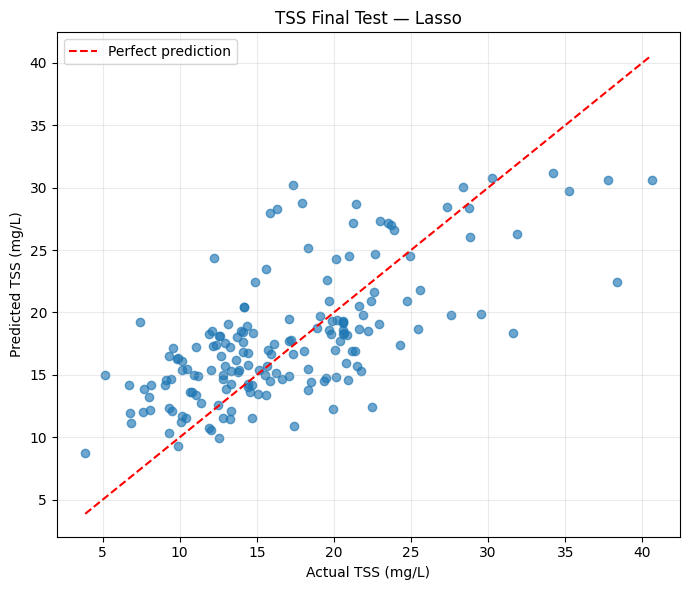

In [607]:
#. Plot actual versus predicted test TSS



tss_test_plot_min = min(
    tss_test_actual.min(),
    tss_test_predictions.min()
)

tss_test_plot_max = max(
    tss_test_actual.max(),
    tss_test_predictions.max()
)

plt.figure(figsize=(7, 6))

plt.scatter(
    tss_test_actual,
    tss_test_predictions,
    alpha=0.65
)

plt.plot(
    [tss_test_plot_min, tss_test_plot_max],
    [tss_test_plot_min, tss_test_plot_max],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual TSS (mg/L)")
plt.ylabel("Predicted TSS (mg/L)")
plt.title(f"TSS Final Test — {tss_selected_model_name}")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [608]:
#Create the individual test-prediction table


tss_test_prediction_table = data.loc[
    tss_X_test.index,
    ["record_id", "plant_id", "observation_date"]
].copy()

tss_test_prediction_table["Actual_TSS"] = tss_test_actual
tss_test_prediction_table["Predicted_TSS"] = tss_test_predictions

tss_test_prediction_table["Residual"] = (
    tss_test_prediction_table["Actual_TSS"]
    - tss_test_prediction_table["Predicted_TSS"]
)

tss_test_prediction_table["Absolute_Error"] = (
    tss_test_prediction_table["Residual"].abs()
)

display(tss_test_prediction_table.head(10))

,record_id,plant_id,observation_date,Actual_TSS,Predicted_TSS,Residual,Absolute_Error
680,WQ-0681,WWTP-01,2024-05-16,19.66,18.600639,1.059361,1.059361
681,WQ-0682,WWTP-02,2024-05-16,18.07,16.954491,1.115509,1.115509
682,WQ-0683,WWTP-03,2024-05-16,14.76,18.383691,-3.623691,3.623691
683,WQ-0684,WWTP-04,2024-05-16,23.01,27.342445,-4.332445,4.332445
684,WQ-0685,WWTP-05,2024-05-16,12.93,17.541333,-4.611333,4.611333
685,WQ-0686,WWTP-01,2024-05-17,14.44,15.759250,-1.319250,1.319250
686,WQ-0687,WWTP-02,2024-05-17,10.13,11.699909,-1.569909,1.569909
687,WQ-0688,WWTP-03,2024-05-17,3.88,8.785622,-4.905622,4.905622
688,WQ-0689,WWTP-04,2024-05-17,19.67,20.891345,-1.221345,1.221345
689,WQ-0690,WWTP-05,2024-05-17,7.62,12.020511,-4.400511,4.400511


In [609]:
#Compare test errors across plants


tss_test_plant_results = (
    tss_test_prediction_table
    .groupby("plant_id")
    .agg(
        Test_Rows=("Absolute_Error", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Residual=("Residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(tss_test_plant_results.round(3))

,Test_Rows,MAE,Mean_Residual
plant_id,,,
WWTP-04,34,5.046,-2.786
WWTP-02,34,5.026,1.158
WWTP-03,34,3.434,-0.538
WWTP-05,34,3.252,-1.252
WWTP-01,34,2.837,-1.339


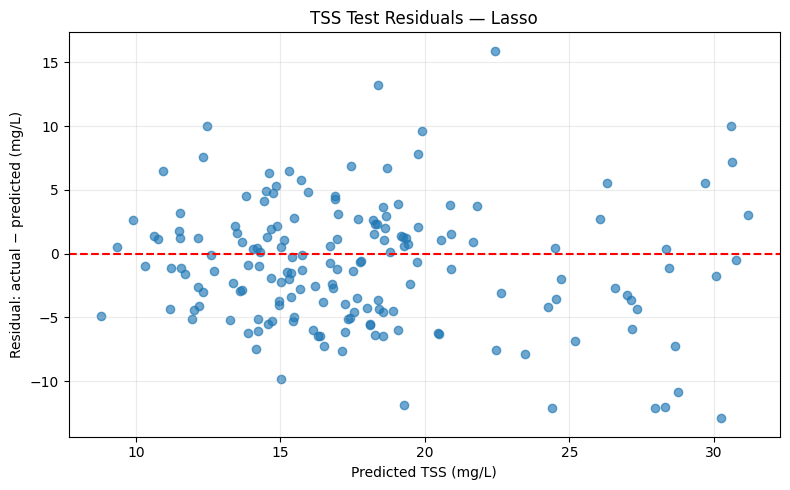

In [610]:
#Plot and save the test residual figure


from pathlib import Path

tss_output_dir = Path("tss_results")
tss_output_dir.mkdir(parents=True, exist_ok=True)

tss_residual_fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    tss_test_prediction_table["Predicted_TSS"],
    tss_test_prediction_table["Residual"],
    alpha=0.65
)

ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted TSS (mg/L)")
ax.set_ylabel("Residual: actual − predicted (mg/L)")
ax.set_title(f"TSS Test Residuals — {tss_selected_model_name}")
ax.grid(alpha=0.25)

tss_residual_fig.tight_layout()

tss_residual_fig.savefig(
    tss_output_dir / "tss_test_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [611]:
#Save the fitted pipeline and result tables

import joblib

joblib.dump(
    {
        "pipeline": tss_final_model,
        "target": tss_target,
        "feature_columns": tss_X_development.columns.tolist(),
        "selection_metric": "Validation MAE",
        "model_name": tss_selected_model_name
    },
    tss_output_dir / "tss_pipeline.joblib"
)

tss_tables_to_save = {
    "tss_training_validation_errors.csv": tss_error_table,
    "tss_training_validation_relative_metrics.csv": tss_relative_table,
    "tss_validation_ranking.csv": tss_validation_ranking,
    "tss_test_metrics.csv": tss_test_results,
    "tss_test_predictions.csv": tss_test_prediction_table
}

for filename, table in tss_tables_to_save.items():
    table.to_csv(tss_output_dir / filename, index=False)

tss_test_plant_results.to_csv(
    tss_output_dir / "tss_test_metrics_by_plant.csv"
)

print("TSS pipeline, result tables and residual plot saved successfully.")
print("Saved folder:", tss_output_dir.resolve())

TSS pipeline, result tables and residual plot saved successfully.
Saved folder: /content/tss_results


In [612]:
#Download everything as one ZIP

import shutil
from google.colab import files

tss_zip_path = shutil.make_archive(
    "/content/tss_results_backup",
    "zip",
    root_dir=str(tss_output_dir.resolve().parent),
    base_dir=tss_output_dir.name
)

files.download(tss_zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Total nitrogen prediction**

In [613]:
#Prepare the inputs and target


tn_target = "effluent_total_nitrogen_mg_l"

tn_valid_mask = data[tn_target].notna()

tn_X = data.loc[
    tn_valid_mask, candidate_feature
].copy()

tn_y = data.loc[
    tn_valid_mask, tn_target
].copy()

tn_dates = pd.to_datetime(
    data.loc[tn_valid_mask, "observation_date"]
)

assert tn_X.index.equals(tn_y.index)
assert tn_target not in tn_X.columns

print("Rows with known total nitrogen:", len(tn_y))
print("Missing target rows excluded:", (~tn_valid_mask).sum())
print("Number of inputs:", tn_X.shape[1])

Rows with known total nitrogen: 850
Missing target rows excluded: 0
Number of inputs: 17


In [614]:
#Apply the existing chronological boundaries




tn_train_mask = tn_dates < validation_start

tn_validation_mask = (
    (tn_dates >= validation_start)
    & (tn_dates < test_start)
)

tn_test_mask = tn_dates >= test_start

tn_X_train = tn_X.loc[tn_train_mask].copy()
tn_y_train = tn_y.loc[tn_train_mask].copy()

tn_X_validation = tn_X.loc[tn_validation_mask].copy()
tn_y_validation = tn_y.loc[tn_validation_mask].copy()

tn_X_test = tn_X.loc[tn_test_mask].copy()
tn_y_test = tn_y.loc[tn_test_mask].copy()

In [615]:
#Verify the split


tn_split_rows = []

for split_name, split_X, split_y in [
    ("Train", tn_X_train, tn_y_train),
    ("Validation", tn_X_validation, tn_y_validation),
    ("Test", tn_X_test, tn_y_test)
]:
    assert split_X.index.equals(split_y.index)
    assert len(split_y) > 0

    split_dates = tn_dates.loc[split_X.index]

    tn_split_rows.append({
        "Split": split_name,
        "Rows": len(split_y),
        "First_Observation": split_dates.min(),
        "Last_Observation": split_dates.max()
    })

assert tn_X_train.index.intersection(tn_X_validation.index).empty
assert tn_X_train.index.intersection(tn_X_test.index).empty
assert tn_X_validation.index.intersection(tn_X_test.index).empty

assert (
    tn_dates.loc[tn_X_train.index].max()
    < tn_dates.loc[tn_X_validation.index].min()
)

assert (
    tn_dates.loc[tn_X_validation.index].max()
    < tn_dates.loc[tn_X_test.index].min()
)

assert (
    len(tn_y_train) + len(tn_y_validation) + len(tn_y_test)
    == len(tn_y)
)

display(pd.DataFrame(tn_split_rows))
print("Total nitrogen split checks passed.")

,Split,Rows,First_Observation,Last_Observation
0,Train,510,2024-01-01,2024-04-11
1,Validation,170,2024-04-12,2024-05-15
2,Test,170,2024-05-16,2024-06-18


Total nitrogen split checks passed.


In [616]:
#Train and compare the models

tn_comparison = compare_regression_models(
    model_definitions=models,
    preprocessing=preprocessor,
    X_train=tn_X_train,
    y_train=tn_y_train,
    X_validation=tn_X_validation,
    y_validation=tn_y_validation
)

tn_fitted_models = tn_comparison["fitted_models"]
tn_predictions = tn_comparison["predictions"]
tn_metrics = tn_comparison["metrics"]
tn_validation_ranking = tn_comparison["validation_ranking"]
tn_model_order = tn_comparison["model_order"]

print(f"Completed comparison for {len(tn_fitted_models)} models.")

Completed comparison for 9 models.


In [617]:
#Display both tables and the validation ranking

tn_error_table = tn_metrics[
    ["Model", "Split", "MAE", "MSE", "RMSE"]
].copy()

tn_relative_table = tn_metrics[
    ["Model", "Split", "R²", "RAE", "RRSE"]
].copy()

print("Total nitrogen — error metrics:")
display(tn_error_table.round(3))

print("Total nitrogen — relative metrics:")
display(tn_relative_table.round(3))

print("Models ranked by validation MAE:")
display(
    tn_validation_ranking[
        ["Model", "MAE", "RMSE", "R²", "RAE", "RRSE"]
    ].round(3)
)

tn_best_model_name = tn_validation_ranking.iloc[0]["Model"]

print("Lowest validation-MAE model:", tn_best_model_name)

Total nitrogen — error metrics:


,Model,Split,MAE,MSE,RMSE
0,Linear Regression,Train,1.354,2.897,1.702
1,Linear Regression,Validation,1.461,3.459,1.860
2,Ridge,Train,1.353,2.897,1.702
3,Ridge,Validation,1.461,3.461,1.860
4,Lasso,Train,1.384,3.062,1.750
5,Lasso,Validation,1.493,3.621,1.903
6,Random Forest,Train,0.892,1.288,1.135
7,Random Forest,Validation,1.525,3.772,1.942
8,Gradient Boosting,Train,1.048,1.703,1.305
9,Gradient Boosting,Validation,1.579,3.998,1.999


Total nitrogen — relative metrics:


,Model,Split,R²,RAE,RRSE
0,Linear Regression,Train,0.709,0.545,0.540
1,Linear Regression,Validation,0.630,0.594,0.608
2,Ridge,Train,0.709,0.545,0.540
3,Ridge,Validation,0.630,0.594,0.608
4,Lasso,Train,0.692,0.557,0.555
5,Lasso,Validation,0.613,0.607,0.622
6,Random Forest,Train,0.871,0.359,0.360
7,Random Forest,Validation,0.597,0.620,0.635
8,Gradient Boosting,Train,0.829,0.422,0.414
9,Gradient Boosting,Validation,0.573,0.642,0.654


Models ranked by validation MAE:


,Model,MAE,RMSE,R²,RAE,RRSE
0,Linear Regression,1.461,1.860,0.630,0.594,0.608
1,Ridge,1.461,1.860,0.630,0.594,0.608
2,Lasso,1.493,1.903,0.613,0.607,0.622
3,Random Forest,1.525,1.942,0.597,0.620,0.635
4,Gradient Boosting,1.579,1.999,0.573,0.642,0.654
5,Decision Tree,1.738,2.203,0.481,0.707,0.720
6,KNN,1.793,2.272,0.448,0.729,0.743
7,SVR,1.808,2.242,0.463,0.735,0.733
8,Mean Baseline,2.483,3.099,-0.027,1.010,1.013


Lowest validation-MAE model: Linear Regression
